# Jupyter Notebook 1. EDA и подготовка данных

**Стажёр:** [Дмитрий]

На входе — сырые данные из таблиц трёх видов: `listings`, `calendar`, `reviews`.
На выходе вы должны создать датасет для обучения модели.

## 1. Подключение библиотек

In [3]:
!pip install boto3 -q
!pip install python-dotenv -q
!pip install phik -q

In [ ]:
# Здесь все необходимые импорты
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import joblib
from dotenv import load_dotenv
from sqlalchemy import create_engine
import unicodedata

import pickle


import re
from collections import Counter


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [5]:

load_dotenv("connect.env")

DB_CONFIG = {
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD"),
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "db": os.getenv("DB_NAME"),
}

connection_string = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['db']}?sslmode=require"
)

engine = create_engine(connection_string)

## 2. Загрузка и первичный осмотр данных

Загрузите таблицы. Для каждой зафиксируйте размер, типы данных, пропуски и ключевые наблюдения.

In [6]:
listings_tables = [
    "amsterdam_listings",
    "chicago_listings",
    "la_listings",
    "london_listings",
    "lyon_listings",
    "munich_listings",
    "nyc_listings",
    "paris_listings",
    "toronto_listings",
    "vienna_listings"
]

listings_dfs = []

for table in listings_tables:
    df = pd.read_sql(f"SELECT * FROM final_project.{table}", engine)
    df["city"] = table.replace("_listings", "")
    listings_dfs.append(df)

listings_raw = pd.concat(listings_dfs, ignore_index=True)

print("SHAPE:", listings_raw.shape)
print("\nCOLUMNS:", listings_raw.shape[1])

display(listings_raw.head())

print("\nDTYPES:")
print(listings_raw.dtypes.value_counts())

print("\nMISSING TOP:")
missing = listings_raw.isna().mean().sort_values(ascending=False)
print(missing.head(15))

dup_count = listings_raw.duplicated(subset=["id"]).sum()

print("DUPLICATES BY ID:", dup_count)


SHAPE: (661425, 65)

COLUMNS: 65


,id,source,name,description,neighborhood_overview,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,27886.0,city scrape,"Романтический, стильный плавучий дом типа «пос...",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",97647.0,2010-03-23,within an hour,100%,97%,...,4.93,4.90,4.78,False,1.0,0.0,1.0,0.0,1.87,amsterdam
1,28871.0,city scrape,Комфортабельный двухместный номер,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",124245.0,2010-05-13,within an hour,100%,99%,...,4.94,4.93,4.83,False,2.0,0.0,2.0,0.0,3.99,amsterdam
2,29051.0,city scrape,Комфортабельный одноместный/двухместный номер,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,124245.0,2010-05-13,within an hour,100%,99%,...,4.92,4.87,4.79,False,2.0,0.0,2.0,0.0,4.81,amsterdam
3,44391.0,previous scrape,Тихая 2-комнатная квартира в центре Амстердама,Guests greatly appreciate the unique location ...,The appartment is located in the city centre. ...,194779.0,2010-08-08,None,None,None,...,4.90,4.68,4.50,False,1.0,1.0,0.0,0.0,0.23,amsterdam
4,48373.0,previous scrape,Уютный семейный дом на юге Амстердама,Charming modern apartment in the quiet and gre...,Apartment is located between Amsterdamse Bos a...,220434.0,2010-09-01,None,None,None,...,5.00,4.60,5.00,False,1.0,1.0,0.0,0.0,0.19,amsterdam



DTYPES:
float64    40
object     25
Name: count, dtype: int64

MISSING TOP:
neighbourhood_group_cleansed    0.752014
neighborhood_overview           0.606760
estimated_revenue_l365d         0.545230
price                           0.485718
host_response_time              0.415790
host_response_rate              0.415790
beds                            0.400641
bathrooms                       0.399205
host_acceptance_rate            0.370737
review_scores_value             0.240862
review_scores_location          0.240857
review_scores_checkin           0.240841
review_scores_communication     0.240705
review_scores_accuracy          0.240702
review_scores_cleanliness       0.240644
dtype: float64
DUPLICATES BY ID: 297341


In [7]:
# =====================================
# Анализ пропусков
# =====================================

missing = (
    listings_raw
    .isna()
    .mean()
    .sort_values(ascending=False)
)

missing = (
    missing[missing > 0]
    .rename("missing_share")
    .to_frame()
)

display(missing.head(20))


,missing_share
neighbourhood_group_cleansed,0.752014
neighborhood_overview,0.606760
estimated_revenue_l365d,0.545230
price,0.485718
host_response_time,0.415790
host_response_rate,0.415790
beds,0.400641
bathrooms,0.399205
host_acceptance_rate,0.370737
review_scores_value,0.240862


In [8]:
# =====================================
# Анализ дубликатов
# =====================================

dup_count = listings_raw.duplicated(subset=["id"]).sum()

print(f"Количество повторяющихся id: {dup_count:,}")

print("\nКоличество различных source:")

display(
    listings_raw["source"]
    .value_counts()
)

print("\nКоличество записей на один id:")

display(
    listings_raw["id"]
    .value_counts()
    .head(10)
)

Количество повторяющихся id: 297,341

Количество различных source:


source
city scrape        397638
previous scrape    263787
Name: count, dtype: int64


Количество записей на один id:


id
2.788600e+04    2
1.526396e+18    2
1.525732e+18    2
1.525730e+18    2
1.525726e+18    2
1.525678e+18    2
1.525641e+18    2
1.526502e+18    2
1.526408e+18    2
1.526295e+18    2
Name: count, dtype: int64

In [9]:
# =====================================
# Анализ аномалий
# =====================================

numeric_cols = [
    "price",
    "accommodates",
    "bathrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "review_scores_rating"
]

for col in numeric_cols:

    print("=" * 60)
    print(col)

    print(listings_raw[col].describe())

    print("\nКоличество нулей:",
          (listings_raw[col] == 0).sum())


# сначала преобразуем цену

price_tmp = (
    listings_raw["price"]
    .astype(str)
    .str.replace(r"[$€,]", "", regex=True)
)

price_tmp = pd.to_numeric(price_tmp, errors="coerce")

print(price_tmp.describe())

print()

print("Пропусков:", price_tmp.isna().sum())

print("Нулевых цен:", (price_tmp == 0).sum())

print("Отрицательных цен:", (price_tmp < 0).sum())

price
count     340159
unique     12539
top       $90.00
freq        3235
Name: price, dtype: object

Количество нулей: 0
accommodates
count    661425.000000
mean          3.342727
std           2.127920
min           1.000000
25%           2.000000
50%           2.000000
75%           4.000000
max          16.000000
Name: accommodates, dtype: float64

Количество нулей: 0
bathrooms
count    397381.000000
mean          1.349034
std           0.789438
min           0.000000
25%           1.000000
50%           1.000000
75%           1.500000
max          42.000000
Name: bathrooms, dtype: float64

Количество нулей: 2342
beds
count    396431.000000
mean          1.946112
std           1.459711
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          50.000000
Name: beds, dtype: float64

Количество нулей: 9280
minimum_nights
count    661376.000000
mean         22.711131
std          66.715209
min           0.000000
25%           2.000000
50%  

In [10]:
calendar_tables = [
    "amsterdam_calendars",
    "chicago_calendars",
    "la_calendars",
    "london_calendars",
    "lyon_calendars",
    "munich_calendars",
    "nyc_calendars",
    "paris_calendars",
    "toronto_calendars",
    "vienna_calendars"
]

calendar_info = []

for table in calendar_tables:
    query = f"""
    SELECT COUNT(*) AS rows
    FROM final_project.{table}
    """
    
    rows = pd.read_sql(query, engine).iloc[0, 0]

    calendar_info.append({
        "table": table,
        "rows": rows
    })

calendar_info = pd.DataFrame(calendar_info)
calendar_info

,table,rows
0,amsterdam_calendars,3825200
1,chicago_calendars,3161995
2,la_calendars,16638552
3,london_calendars,35357974
4,lyon_calendars,3521155
5,munich_calendars,3020010
6,nyc_calendars,13302439
7,paris_calendars,29876359
8,toronto_calendars,5758259
9,vienna_calendars,5154902


In [11]:
calendar_sample = []

for table in calendar_tables:

    query = f"""
    SELECT *
    FROM final_project.{table}
    LIMIT 5000
    """

    df = pd.read_sql(query, engine)

    df["city"] = table.replace("_calendars", "")

    calendar_sample.append(df)

calendar_sample = pd.concat(calendar_sample, ignore_index=True)

calendar_sample.shape
calendar_sample.info()

calendar_sample.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   listing_id      50000 non-null  float64
 1   date            50000 non-null  object 
 2   available       50000 non-null  bool   
 3   price           0 non-null      object 
 4   adjusted_price  0 non-null      object 
 5   minimum_nights  50000 non-null  float64
 6   maximum_nights  50000 non-null  float64
 7   city            50000 non-null  object 
dtypes: bool(1), float64(3), object(4)
memory usage: 2.7+ MB


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights,city
0,538723.0,2025-09-11,False,None,None,5.0,30.0,amsterdam
1,538723.0,2025-09-12,False,None,None,5.0,30.0,amsterdam
2,538723.0,2025-09-13,False,None,None,5.0,30.0,amsterdam
3,538723.0,2025-09-14,False,None,None,5.0,30.0,amsterdam
4,538723.0,2025-09-15,False,None,None,5.0,30.0,amsterdam


In [12]:
# =====================================
# Анализ calendar
# =====================================

print(calendar_sample.isna().mean())

print("\nДубликаты:")

print(calendar_sample.duplicated().sum())

print("\nAvailable:")

display(calendar_sample["available"].value_counts())

print("\nMinimum nights:")

display(calendar_sample["minimum_nights"].describe())

print("\nMaximum nights:")

display(calendar_sample["maximum_nights"].describe())

listing_id        0.0
date              0.0
available         0.0
price             1.0
adjusted_price    1.0
minimum_nights    0.0
maximum_nights    0.0
city              0.0
dtype: float64

Дубликаты:
0

Available:


available
False    28444
True     21556
Name: count, dtype: int64


Minimum nights:


count    50000.00000
mean        53.28706
std        111.27917
min          1.00000
25%          2.00000
50%          4.00000
75%         30.00000
max        365.00000
Name: minimum_nights, dtype: float64


Maximum nights:


count    50000.00000
mean       600.93172
std        494.74666
min          4.00000
25%         60.00000
50%        365.00000
75%       1125.00000
max       1125.00000
Name: maximum_nights, dtype: float64

In [13]:
review_tables = [
    "amsterdam_reviews",
    "chicago_reviews",
    "la_reviews",
    "london_reviews",
    "lyon_reviews",
    "munich_reviews",
    "nyc_reviews",
    "paris_reviews",
    "toronto_reviews",
    "vienna_reviews"
]

reviews_info = []

for table in review_tables:

    query = f"""
    SELECT COUNT(*) AS rows
    FROM final_project.{table}
    """

    rows = pd.read_sql(query, engine).iloc[0,0]

    reviews_info.append({
        "table": table,
        "rows": rows
    })

reviews_info = pd.DataFrame(reviews_info)

reviews_info

,table,rows
0,amsterdam_reviews,515387
1,chicago_reviews,519761
2,la_reviews,1891200
3,london_reviews,2270643
4,lyon_reviews,450807
5,munich_reviews,234949
6,nyc_reviews,1019386
7,paris_reviews,2360017
8,toronto_reviews,685095
9,vienna_reviews,658531


In [14]:
reviews_sample = []

for table in review_tables:

    query = f"""
    SELECT *
    FROM final_project.{table}
    LIMIT 5000
    """

    df = pd.read_sql(query, engine)

    df["city"] = table.replace("_reviews", "")

    reviews_sample.append(df)

reviews_sample = pd.concat(reviews_sample, ignore_index=True)

reviews_sample.info()

reviews_sample.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   listing_id   50000 non-null  float64
 1   id           50000 non-null  float64
 2   date         50000 non-null  object 
 3   reviewer_id  50000 non-null  float64
 4   comments     49994 non-null  object 
 5   city         50000 non-null  object 
dtypes: float64(3), object(3)
memory usage: 2.3+ MB


,listing_id,id,date,reviewer_id,comments,city
0,839610.0,33387684.0,2015-05-27,32412055.0,Nice time in nice place! Close to city center!...,amsterdam
1,839610.0,33865462.0,2015-06-01,33521461.0,The host is very friendly and helpful,amsterdam
2,839610.0,47062612.0,2015-09-15,25521258.0,"Michael, Jacob's son was the one to coordinate...",amsterdam
3,839610.0,49847491.0,2015-10-06,32115691.0,Our stay was excelent. The appartment was clea...,amsterdam
4,839610.0,62280485.0,2016-02-13,16551781.0,it's very good! thanks! it's very beautiful al...,amsterdam


In [15]:
# =====================================
# Анализ reviews
# =====================================

print(reviews_sample.isna().mean())

print("\nДубликаты:")

print(reviews_sample.duplicated().sum())

print("\nДлина комментариев")

reviews_sample["comment_length"] = (
    reviews_sample["comments"]
    .fillna("")
    .str.len()
)

display(
    reviews_sample["comment_length"].describe()
)

listing_id     0.00000
id             0.00000
date           0.00000
reviewer_id    0.00000
comments       0.00012
city           0.00000
dtype: float64

Дубликаты:
0

Длина комментариев


count    50000.000000
mean       301.813540
std        273.707859
min          0.000000
25%        122.000000
50%        232.000000
75%        394.000000
max       3527.000000
Name: comment_length, dtype: float64

In [16]:
#аномалии 

**Ключевые наблюдения по данным**

Анализ трёх основных таблиц (listings, calendar, reviews) показал, что данные представляют собой промышленный snapshot-датасет с высокой степенью детализации.

Таблица listings содержит повторяющиеся записи одного объявления, связанные с временными снимками данных. Это указывает на панельную структуру данных и необходимость выбора единой версии объекта перед моделированием.

Таблица calendar имеет крайне высокий объем данных и не может быть загружена целиком в память, что требует использования выборок или агрегирования на уровне SQL. Часть ценовых признаков в доступной выборке отсутствует.

Таблица reviews содержит большие объемы текстовых данных с минимальным количеством пропусков и может быть использована для извлечения дополнительных признаков с помощью методов NLP.

В целом, данные характеризуются как многослойные (структурные, временные и текстовые), что делает задачу прогнозирования спроса комплексной. 

## 3. Расчёт целевой переменной

Рассчитайте `is_high_demand` по формуле из постановки задачи. Проверьте баланс классов и зафикcируйте наблюдения.

In [17]:
#удалить обьявления без цен и баланс 80/20 

Размер выборки: (397638, 65)

Количество объявлений без цены: 61389
Размер после удаления объявлений без цены: (336249, 65)

Количество объектов по классам:
is_high_demand
0    294823
1     41426
Name: count, dtype: int64

Доли классов:
is_high_demand
0    0.877
1    0.123
Name: proportion, dtype: float64


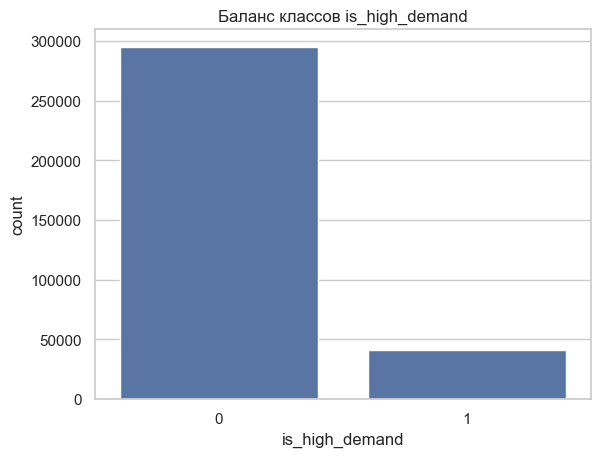

In [18]:
# =====================================
# Расчёт целевой переменной
# =====================================

# Используем только актуальные снимки объявлений
listings = listings_raw[listings_raw["source"] == "city scrape"].copy()

print("Размер выборки:", listings.shape)

# -------------------------------------
# Подготовка признаков для расчета таргета
# -------------------------------------

# Цена хранится в текстовом формате
listings["price"] = (
    listings["price"]
    .astype(str)
    .str.replace(r"[$€,]", "", regex=True)
)

listings["price"] = pd.to_numeric(
    listings["price"],
    errors="coerce"
)

listings["review_scores_rating"] = pd.to_numeric(
    listings["review_scores_rating"],
    errors="coerce"
)

listings["numeric_of_reviews_ltm"] = pd.to_numeric(
    listings["numeric_of_reviews_ltm"],
    errors="coerce"
)

# -------------------------------------
# Обработка пропусков перед расчетом таргета
# -------------------------------------

print("\nКоличество объявлений без цены:",
      listings["price"].isna().sum())

# Без цены невозможно рассчитать price_ratio,
# поэтому такие объявления исключаем.
listings = listings.dropna(subset=["price"])

print("Размер после удаления объявлений без цены:",
      listings.shape)

# -------------------------------------
# Расчет медиан по сегментам
# -------------------------------------

segment_stats = (
    listings
    .groupby(["city", "room_type"])
    .agg(
        median_reviews_ltm=("numeric_of_reviews_ltm", "median"),
        median_price=("price", "median"),
        median_rating=("review_scores_rating", "median")
    )
    .reset_index()
)

listings = listings.merge(
    segment_stats,
    on=["city", "room_type"],
    how="left"
)

# -------------------------------------
# Расчет относительных показателей
# -------------------------------------

listings["price_ratio"] = (
    listings["price"] /
    listings["median_price"]
)

listings["rating_ratio"] = (
    listings["review_scores_rating"] /
    listings["median_rating"]
)

# -------------------------------------
# Расчет целевой переменной
# -------------------------------------

listings["is_high_demand"] = (
    (listings["numeric_of_reviews_ltm"] >
     listings["median_reviews_ltm"])
    &
    (listings["price_ratio"] >= 1)
    &
    (listings["rating_ratio"] >= 1)
).astype(int)

# -------------------------------------
# Анализ баланса классов
# -------------------------------------

class_counts = listings["is_high_demand"].value_counts()

class_ratio = (
    listings["is_high_demand"]
    .value_counts(normalize=True)
    .round(3)
)

print("\nКоличество объектов по классам:")
print(class_counts)

print("\nДоли классов:")
print(class_ratio)

sns.countplot(data=listings, x="is_high_demand")
plt.title("Баланс классов is_high_demand")
plt.show()

**Баланс классов и выводы:**

Для расчета целевой переменной использовались только актуальные записи (city scrape). Перед вычислением таргета были исключены объявления без указанной цены, так как для них невозможно рассчитать показатель price_ratio, входящий в формулу целевой переменной. После удаления таких записей объем выборки сократился с 397 638 до 336 249 объявлений.

Рассчитанная целевая переменная is_high_demand имеет выраженный дисбаланс классов: 87,7% объектов относятся к отрицательному классу и 12,3% — к положительному. Такое распределение объясняется тем, что положительный класс формируется только для объявлений, одновременно удовлетворяющих трем условиям: количество отзывов выше медианы сегмента, цена не ниже медианной и рейтинг не ниже медианного значения.

## 4. Исключение утечек данных

Найдите и исключите все колонки, которые нельзя использовать как признаки. Обоснуйте каждое решение.

In [19]:
# =====================================
# Исключение утечек данных
# =====================================

leakage_cols = [
    # цена использовалась при создании target
    "price",
    # Признаки, напрямую связанные с фактом спроса
    "numeric_of_reviews_ltm",
    "numeric_of_reviews",
    "numeric_of_reviews_l30d",
    "numeric_of_reviews_ly",
    "reviews_per_month",
    "first_review",
    "last_review",

    # Фактическая успешность объекта
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",

    # Доступность после бронирований
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_eoy",

    # Признаки, созданные только для расчёта target
    "median_reviews_ltm",
    "median_price",
    "median_rating",
    "price_ratio",
    "rating_ratio"
]


listings_ml = listings.drop(
    columns=leakage_cols,
    errors="ignore"
)


print("Размер данных после удаления признаков-утечек:")
print(listings_ml.shape)

Размер данных после удаления признаков-утечек:
(336249, 51)


**Исключённые колонки и обоснование:**

Перед обучением модели были удалены признаки, которые могут привести к утечке целевой переменной (**data leakage**) или содержат информацию о уже реализовавшемся спросе.

| Колонка | Причина исключения |
|---------|-------------------|
| `price` | Используется при расчете целевой переменной через показатель `price_ratio`, поэтому модель могла бы частично восстановить правило формирования таргета. |
| `numeric_of_reviews_ltm` | Один из основных компонентов расчета `is_high_demand`, отражает реализовавшийся спрос за последние 12 месяцев. |
| `numeric_of_reviews`, `numeric_of_reviews_l30d`, `numeric_of_reviews_ly`, `reviews_per_month`, `first_review`, `last_review` | Содержат информацию о количестве и истории отзывов, то есть о уже состоявшихся бронированиях. |
| `estimated_occupancy_l365d`, `estimated_revenue_l365d` | Являются производными признаками фактической успешности объявления и напрямую отражают результаты бронирований. |
| `availability_30`, `availability_60`, `availability_90`, `availability_365`, `availability_eoy` | Могут содержать информацию о текущей и будущей загрузке объекта, связанную с фактическим спросом. |

Признак `review_scores_rating` оставлен в модели, так как целевая переменная использует его относительное значение (`rating_ratio`) внутри сегмента `city + room_type`, а абсолютный рейтинг объявления является самостоятельной характеристикой качества объекта.

После удаления потенциальных источников утечки модель обучается только на признаках, доступных до момента прогнозирования, что делает оценку качества более реалистичной и приближенной к условиям промышленного применения.





## 5. EDA

Исследуйте данные. Изучите распределения числовых и категориальных признаков, корреляции с таргетом, паттерны в данных. На основе EDA сформулируйте гипотезы для создания новых признаков с помощью feature engineering.

### 5.1 Числовые признаки


=== id ===


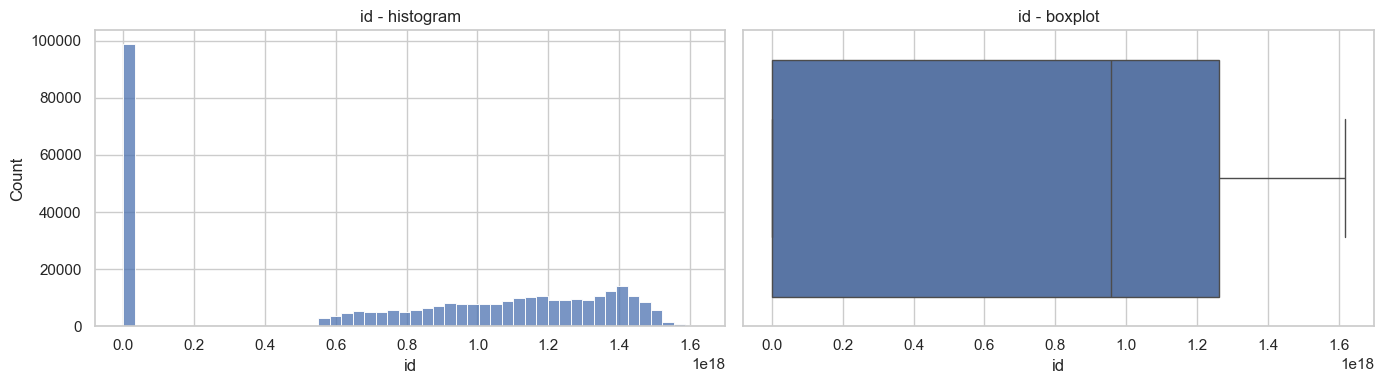


=== host_id ===


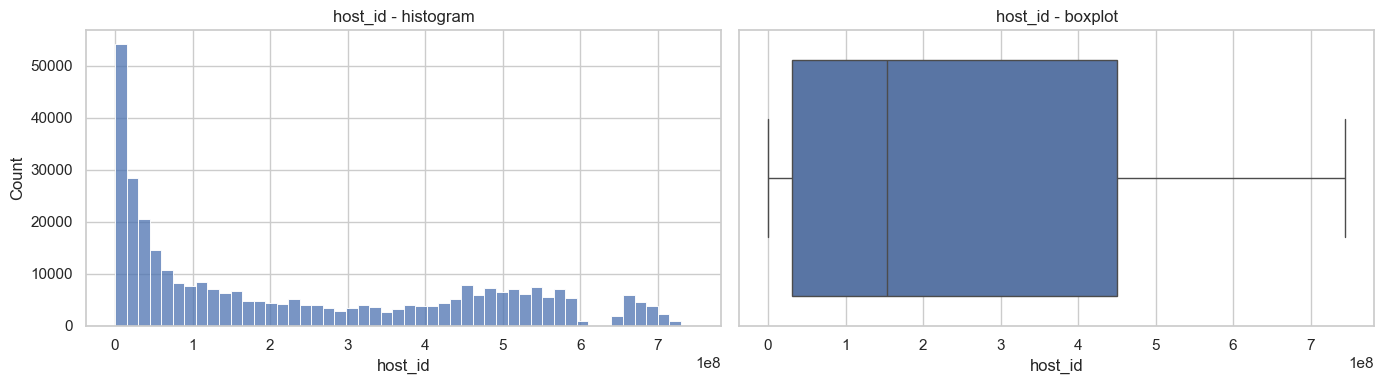


=== host_listings_count ===


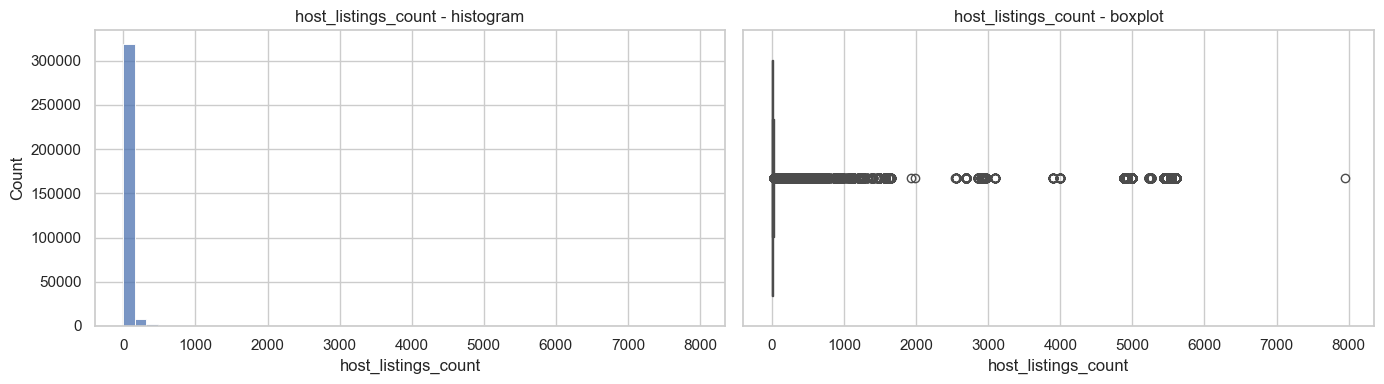


=== host_total_listings_count ===


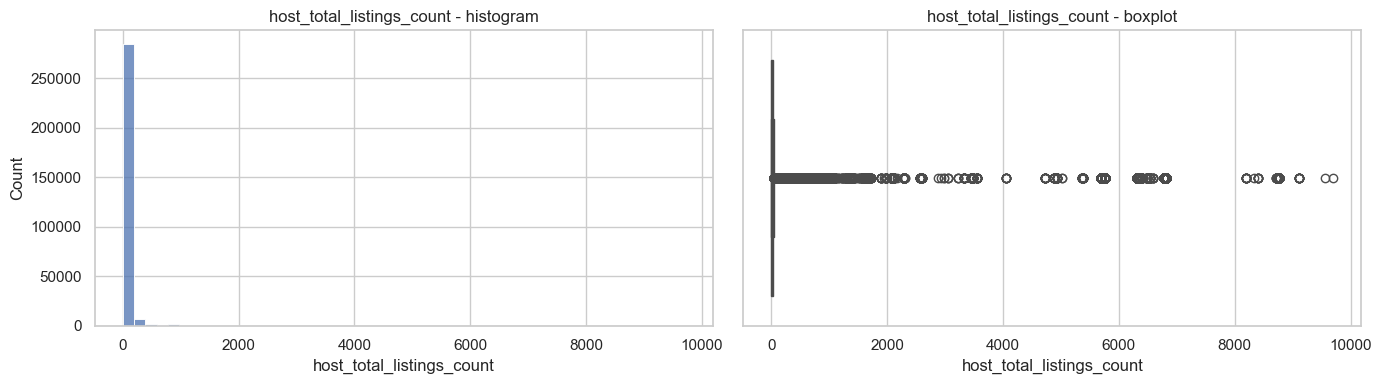


=== latitude ===


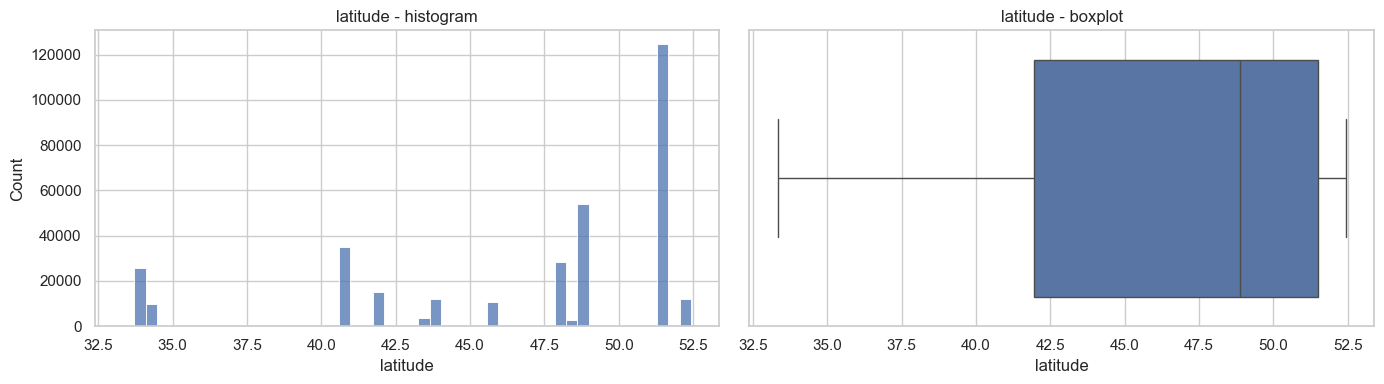


=== longitude ===


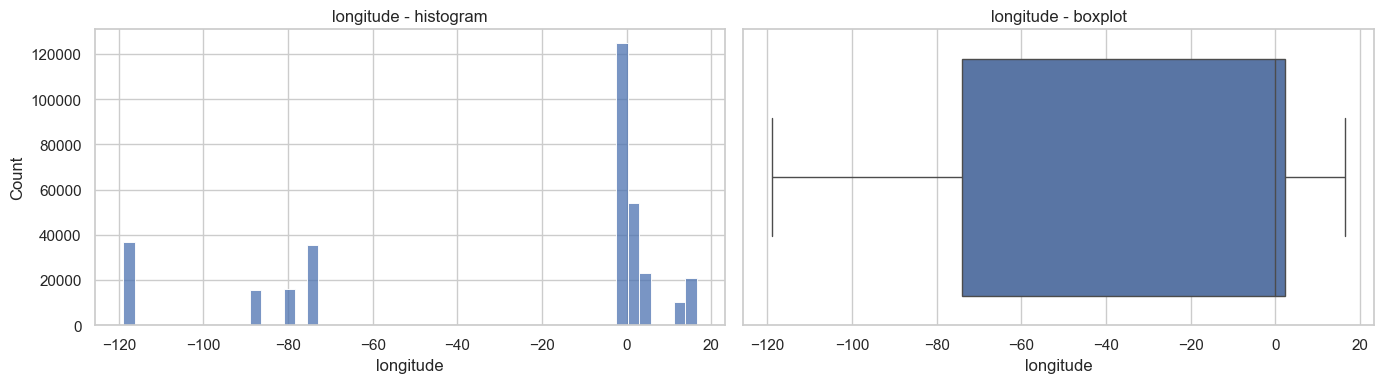


=== accommodates ===


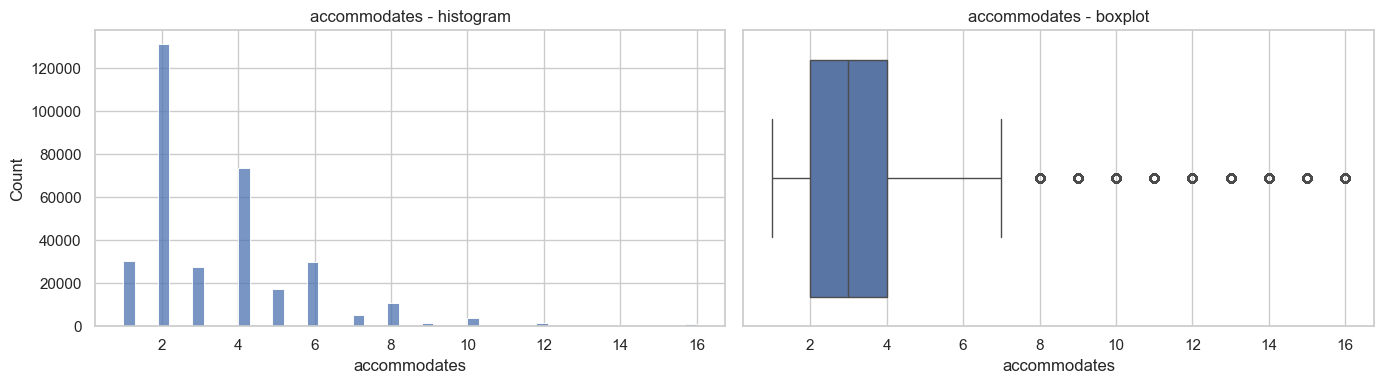


=== bathrooms ===


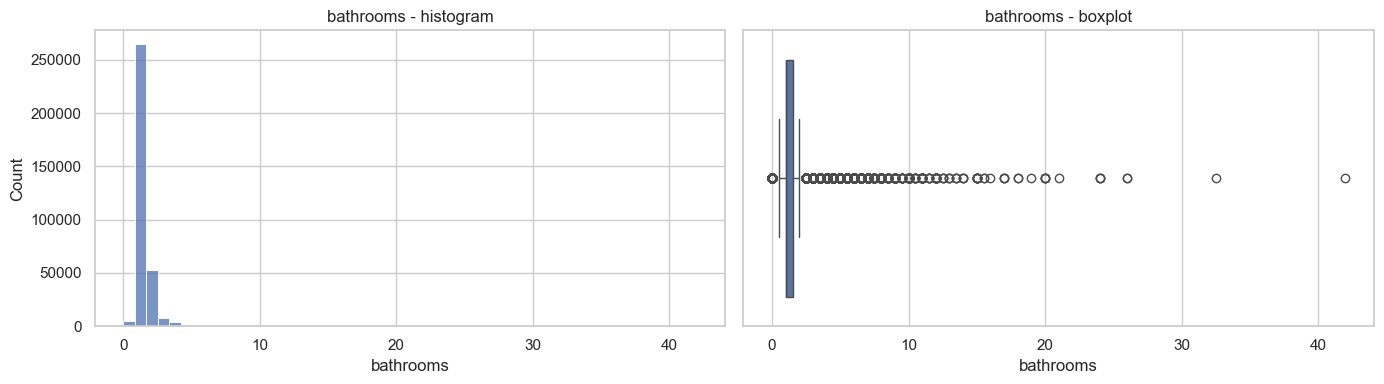


=== bedrooms ===


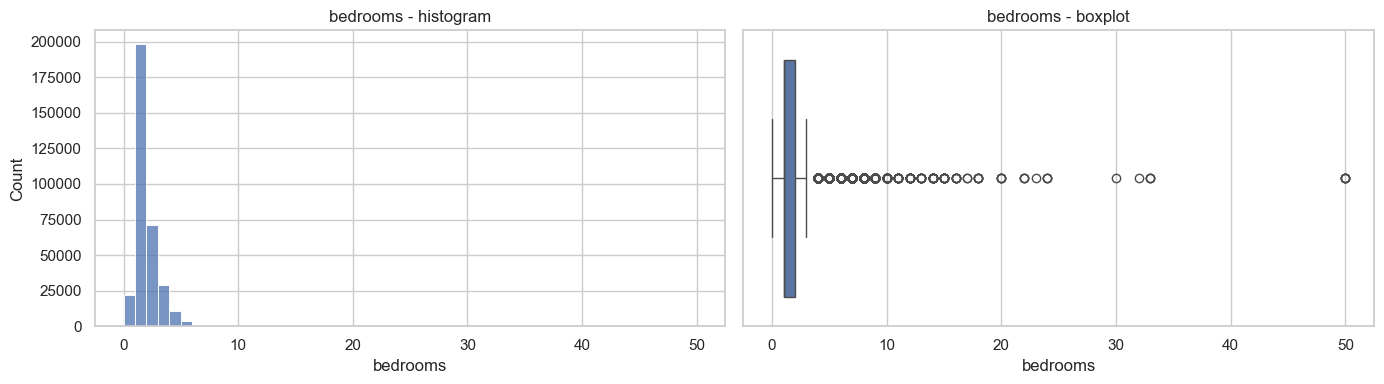


=== beds ===


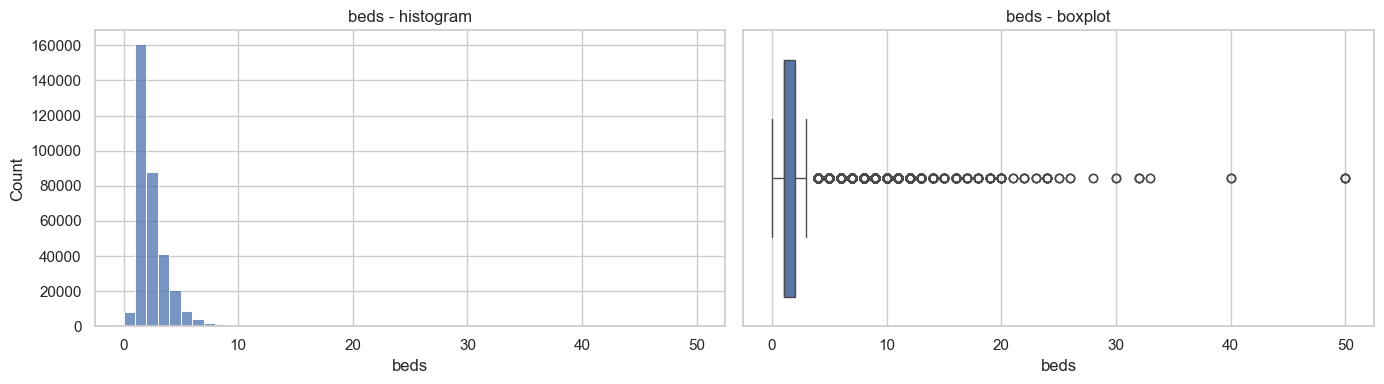


=== minimum_nights ===


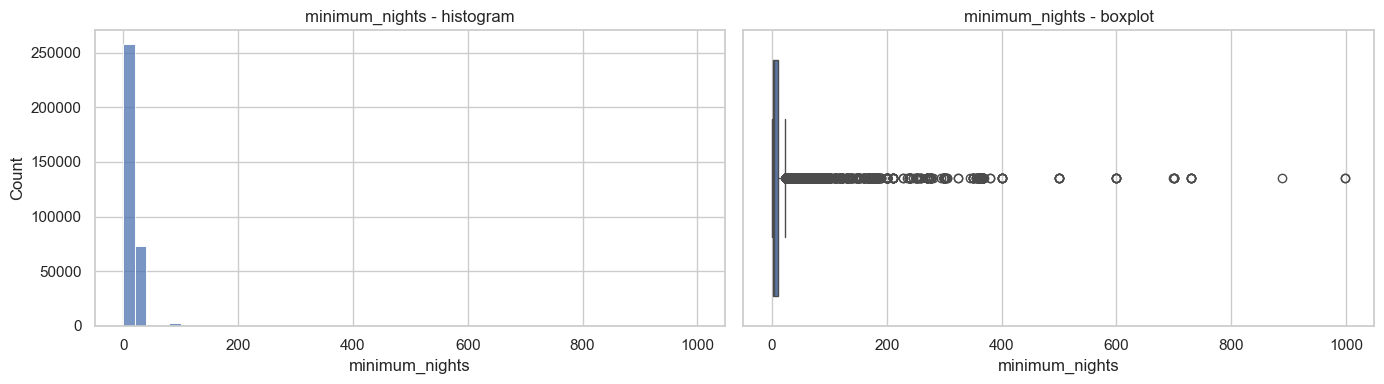


=== maximum_nights ===


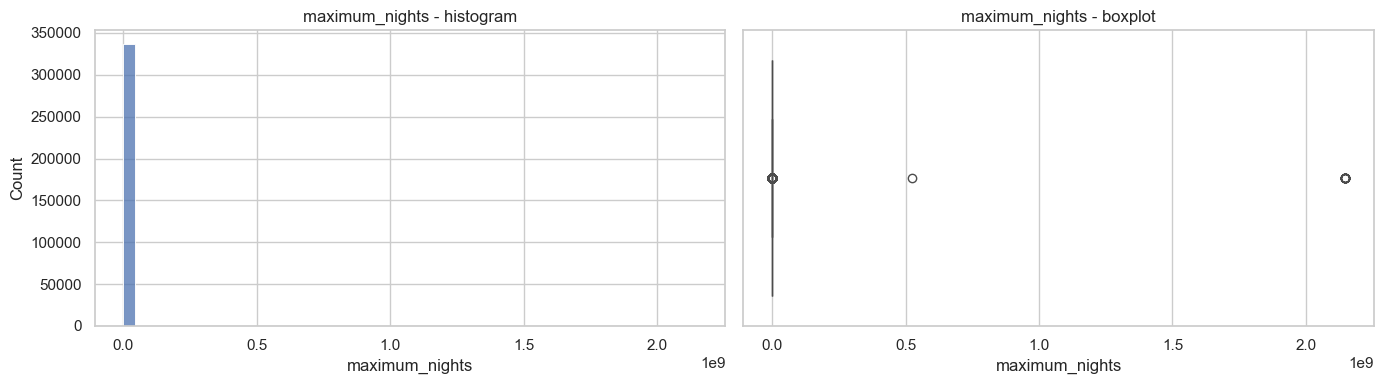


=== minimum_minimum_nights ===


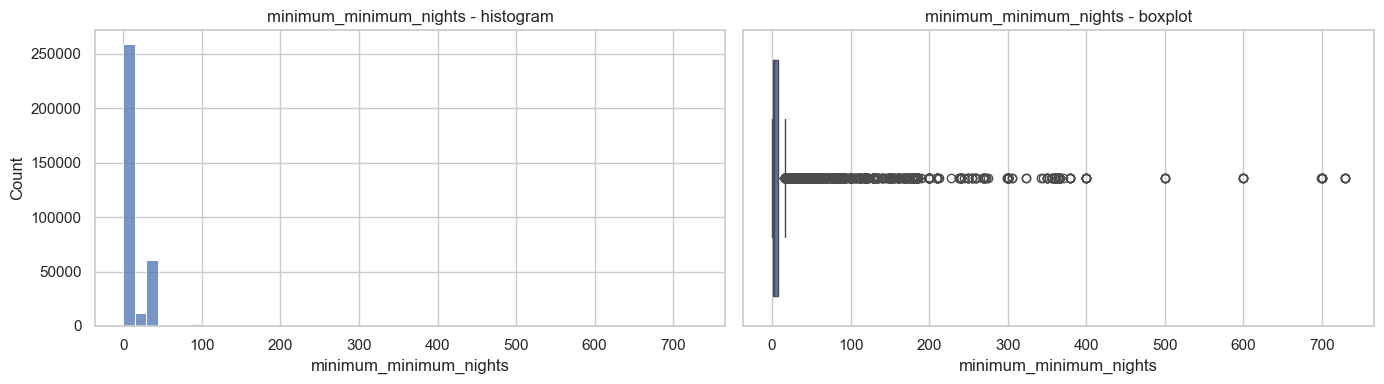


=== maximum_minimum_nights ===


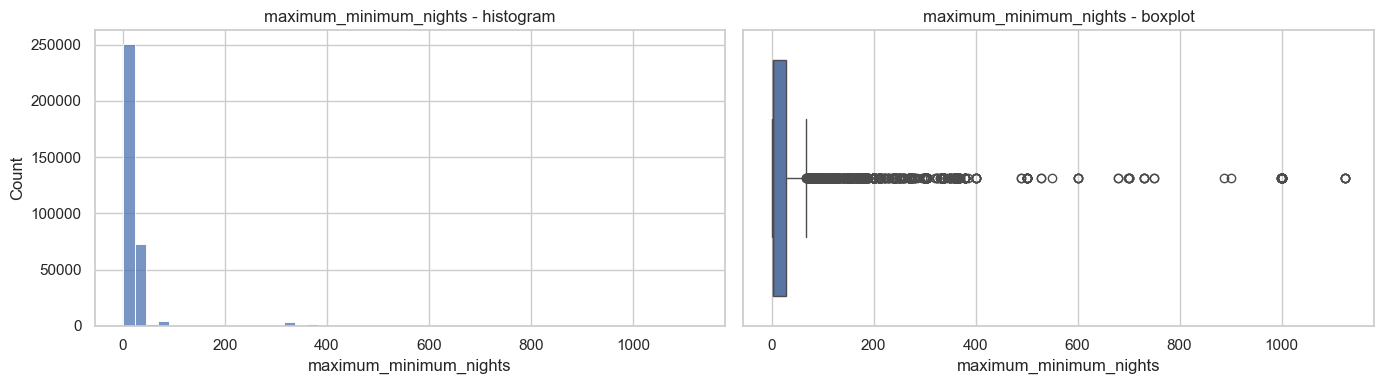


=== minimum_maximum_nights ===


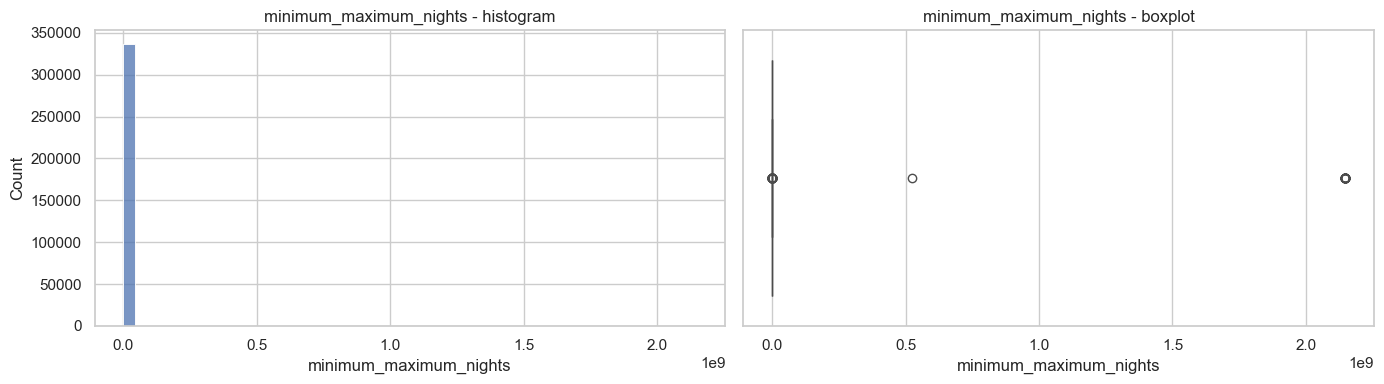


=== maximum_maximum_nights ===


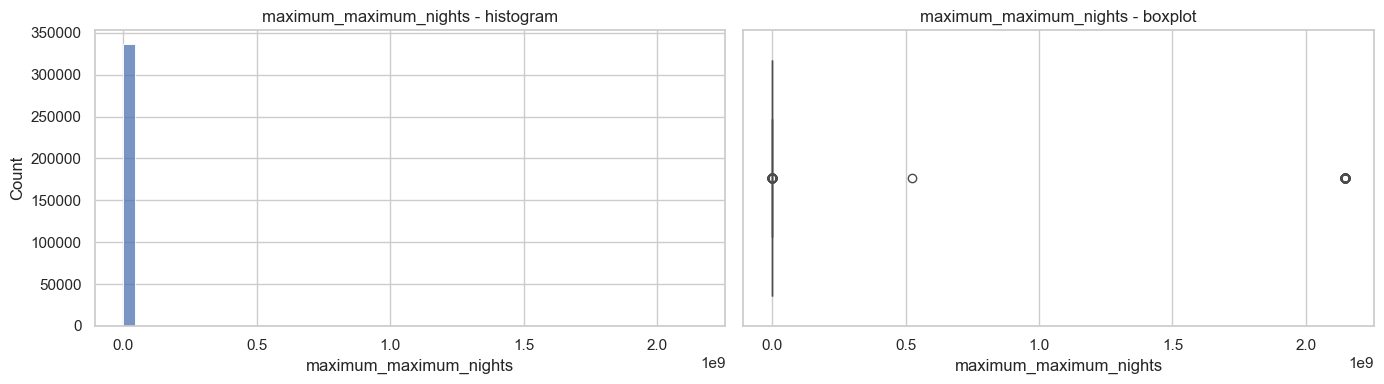


=== minimum_nights_avg_ntm ===


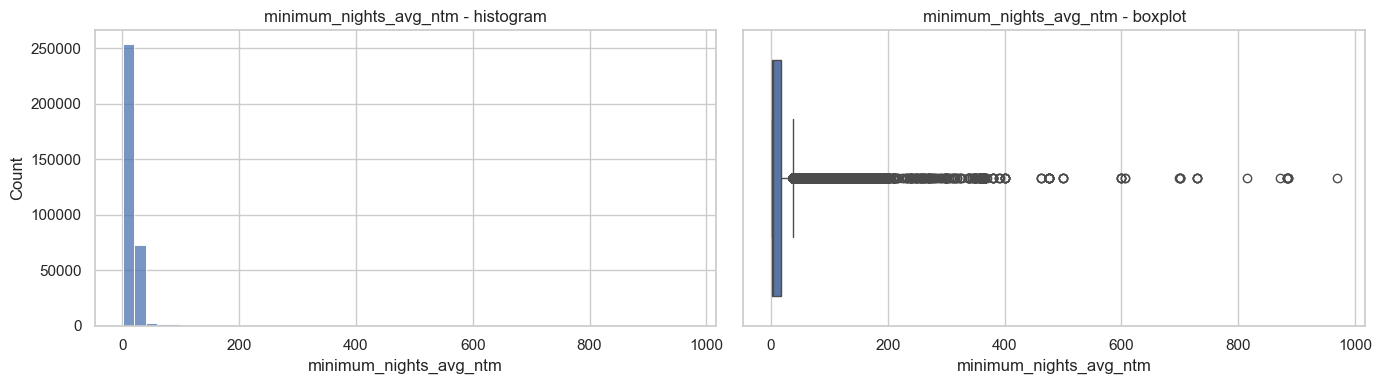


=== maximum_nights_avg_ntm ===


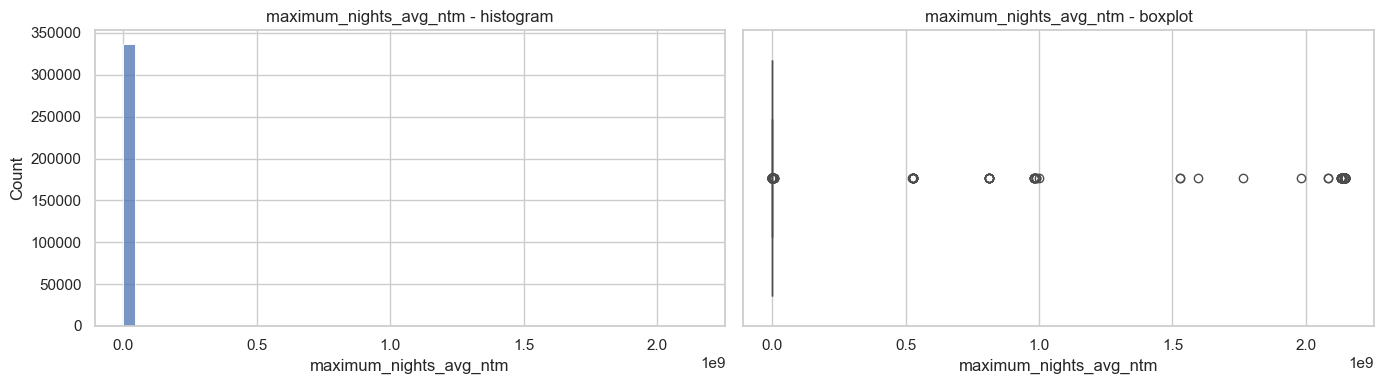


=== review_scores_rating ===


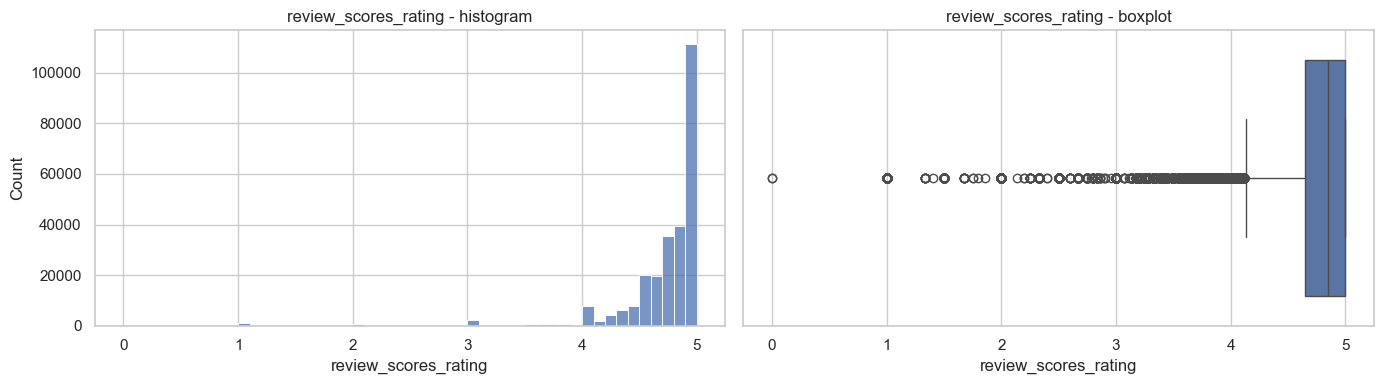


=== review_scores_accuracy ===


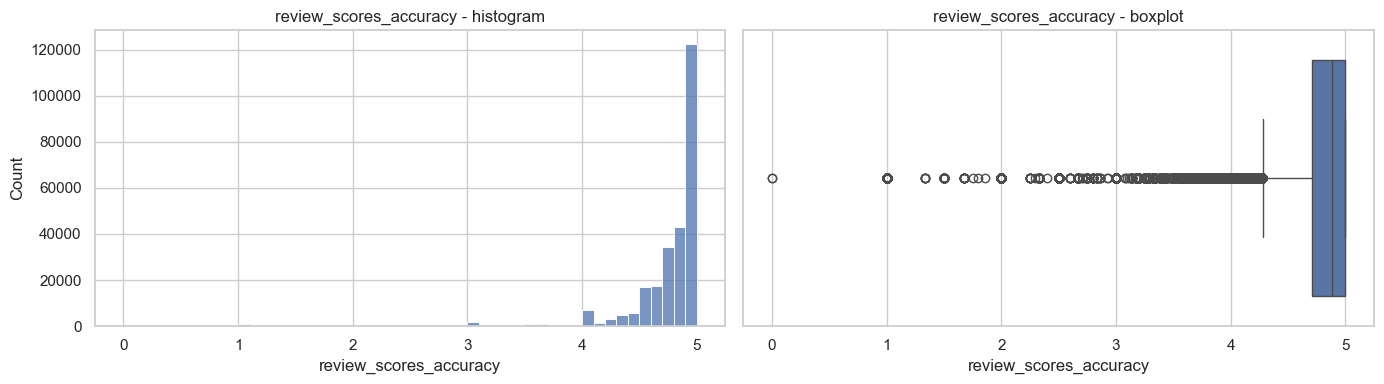


=== review_scores_cleanliness ===


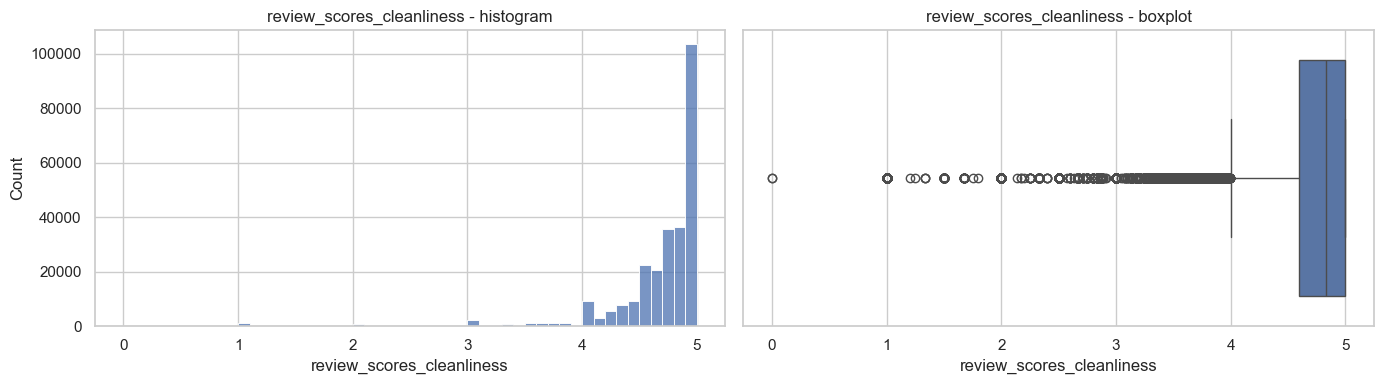


=== review_scores_checkin ===


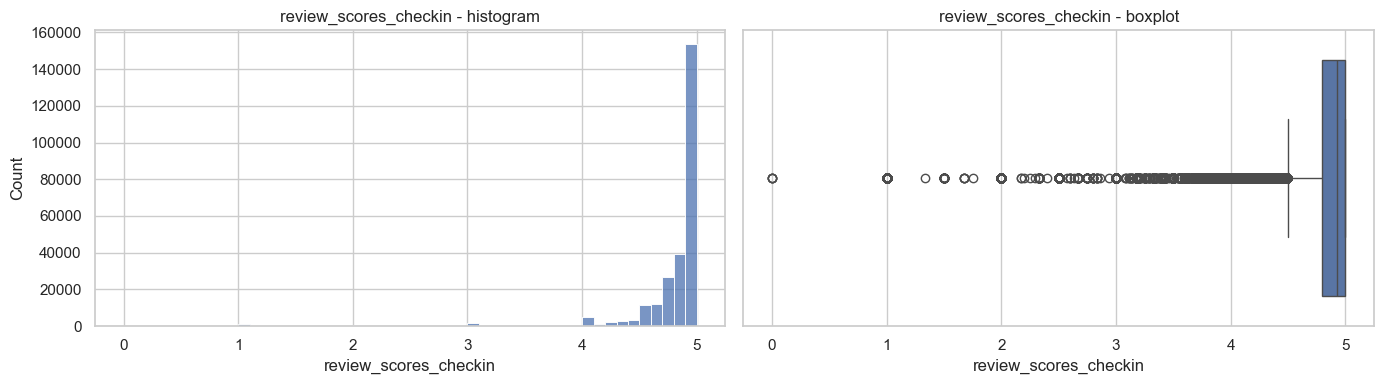


=== review_scores_communication ===


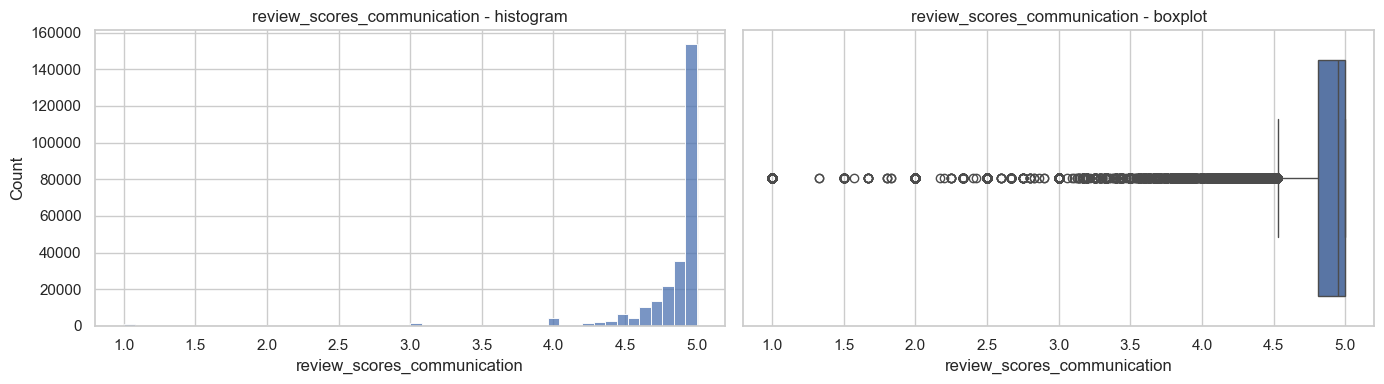


=== review_scores_location ===


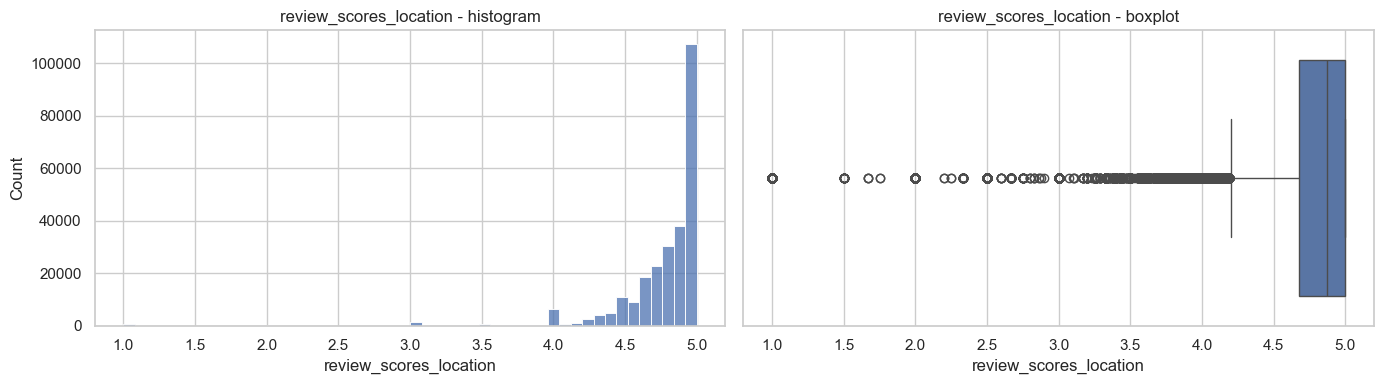


=== review_scores_value ===


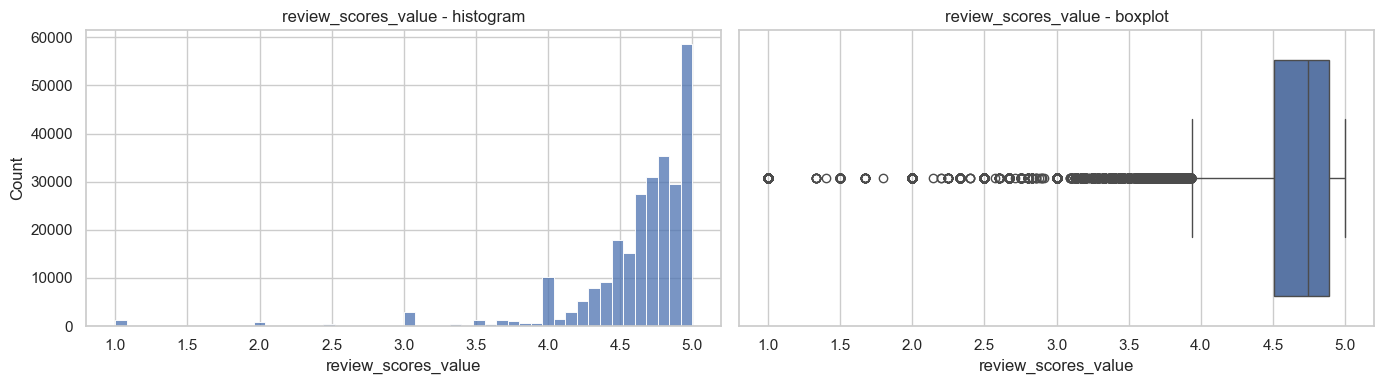


=== calculated_host_listings_count ===


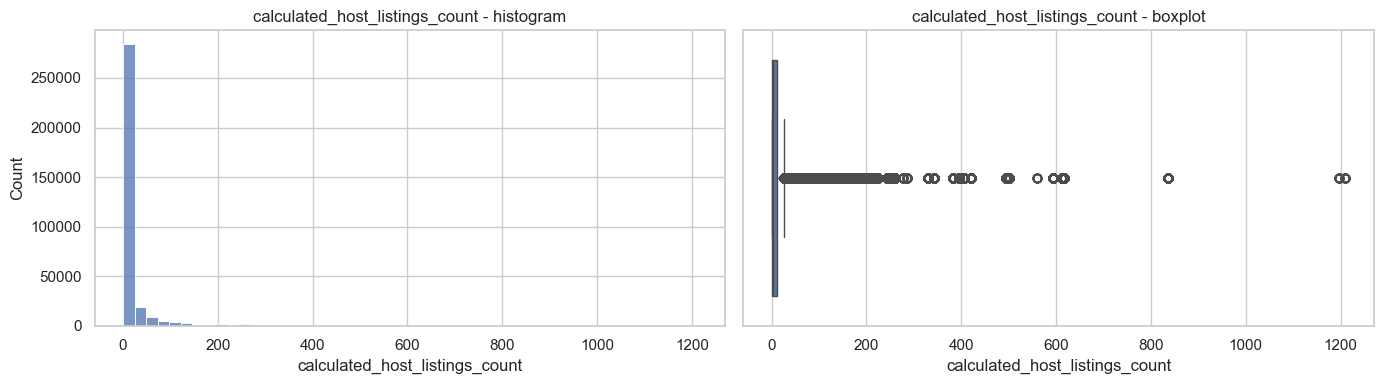


=== calculated_host_listings_count_entire_homes ===


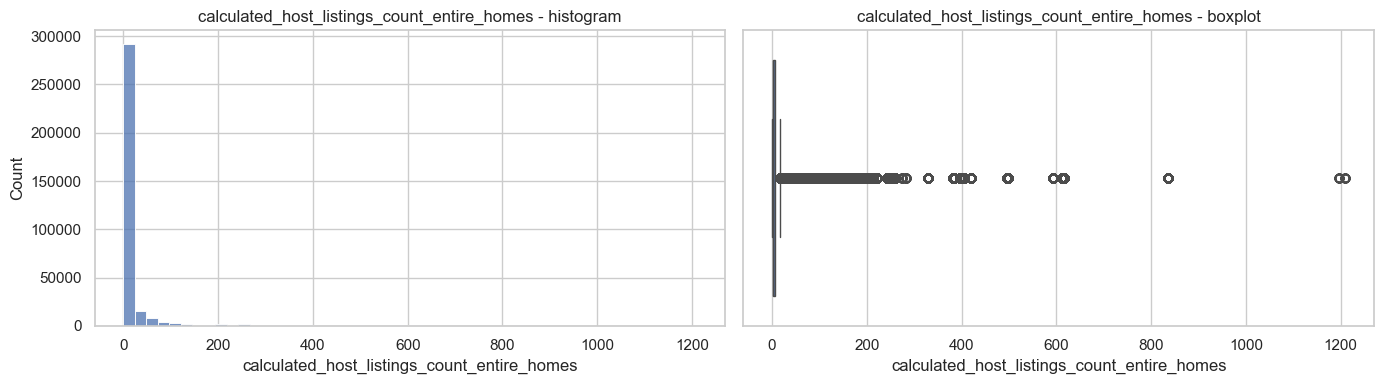


=== calculated_host_listings_count_private_rooms ===


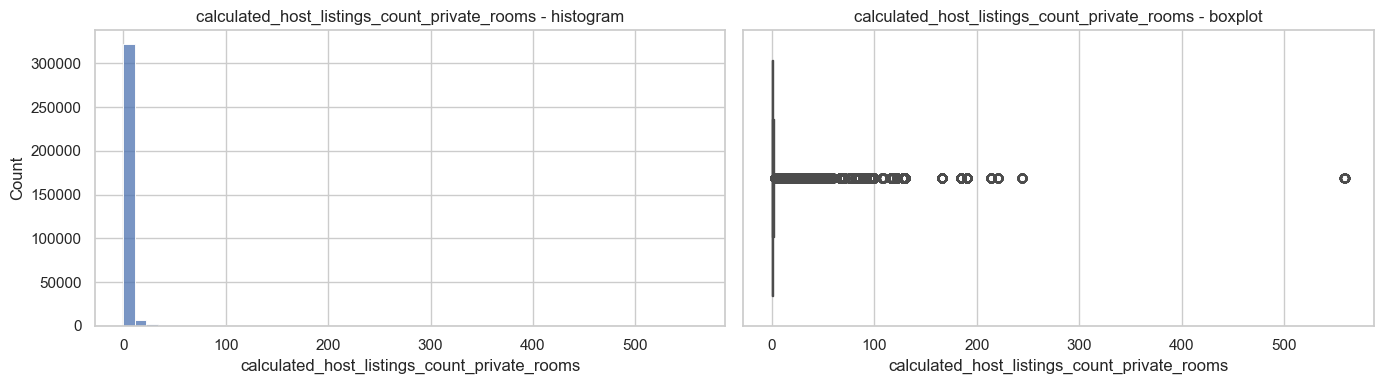


=== calculated_host_listings_count_shared_rooms ===


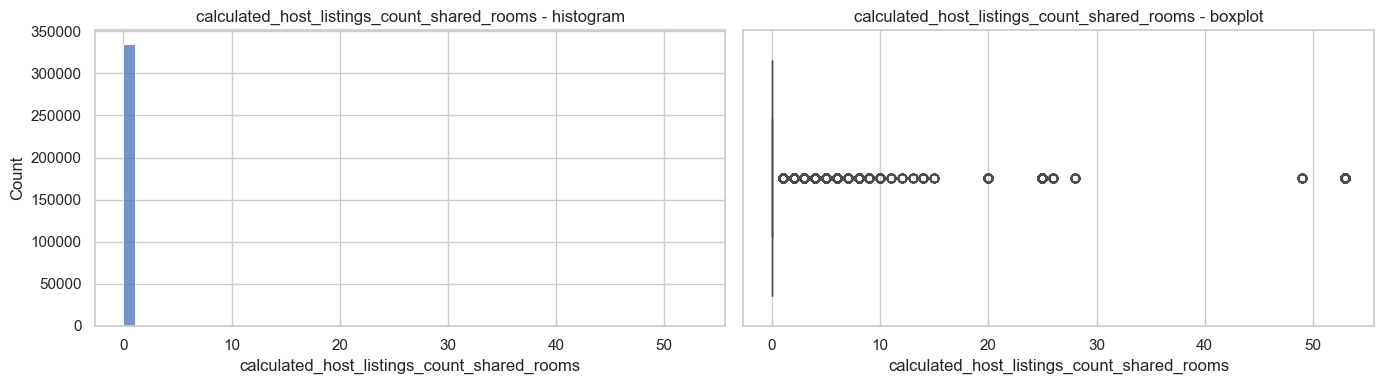

In [20]:
num_cols = listings_ml.select_dtypes(include=np.number).columns.tolist()

# убираем таргет из EDA (чтобы не портить распределения)
num_cols = [col for col in num_cols if col != "is_high_demand"]

for col in num_cols:
    print(f"\n=== {col} ===")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Гистограмма
    sns.histplot(listings_ml[col].dropna(), bins=50, ax=axes[0])
    axes[0].set_title(f"{col} - histogram")
    
    # Boxplot
    sns.boxplot(x=listings_ml[col], ax=axes[1])
    axes[1].set_title(f"{col} - boxplot")
    
    plt.tight_layout()
    plt.show()

**Выводы:**
В данных наблюдается сильная асимметрия распределений и выраженный long-tail эффект (особенно у цены, хостов и отзывов).
Присутствуют существенные выбросы и аномальные значения (например, экстремальные значения maximum_nights и price), которые требуют обработки.
Рейтинги имеют низкую вариативность, поэтому слабо разделяют объекты сами по себе, но полезны в относительных показателях.
Признаки, связанные с активностью (reviews, availability), показывают сильную неоднородность объектов и хорошо отражают спрос.
Derived-признаки (медианы и ratio) уже демонстрируют высокую информативность для сегментации спроса.

### 5.2 Категориальные признаки


=== source ===


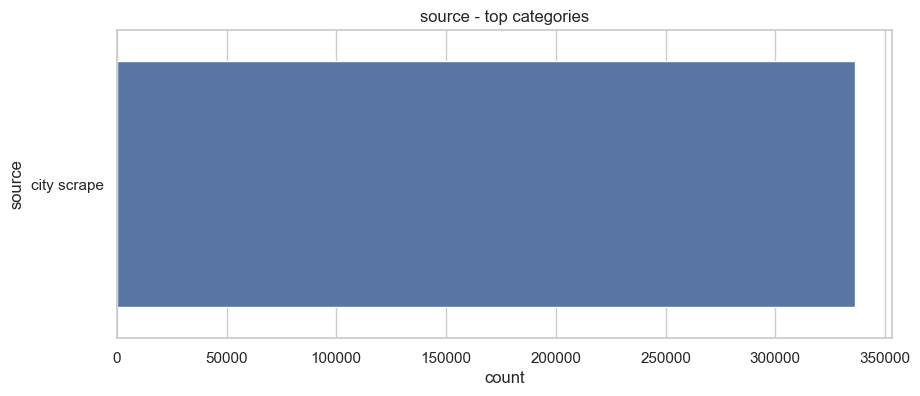


=== host_since ===


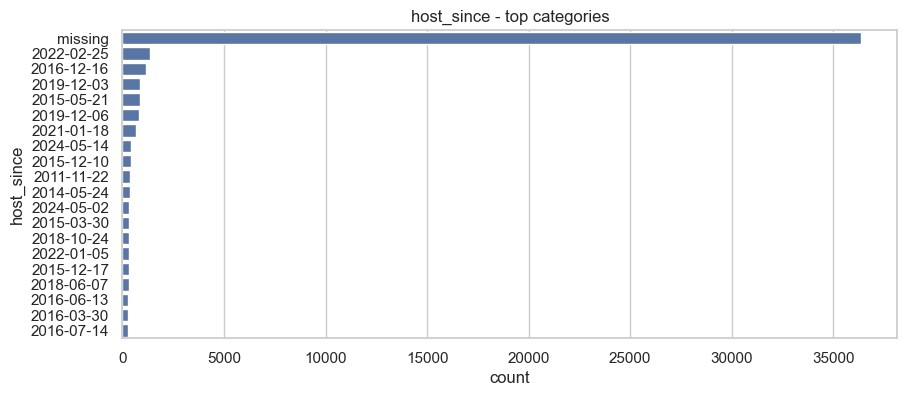


=== host_response_time ===


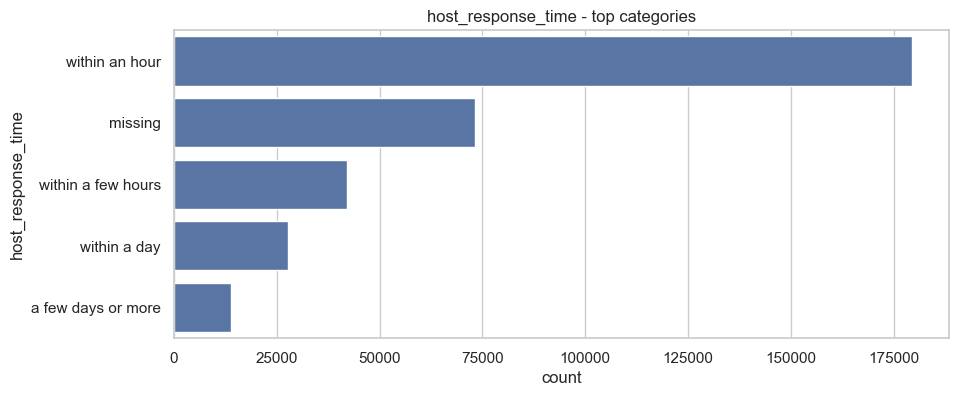


=== host_response_rate ===


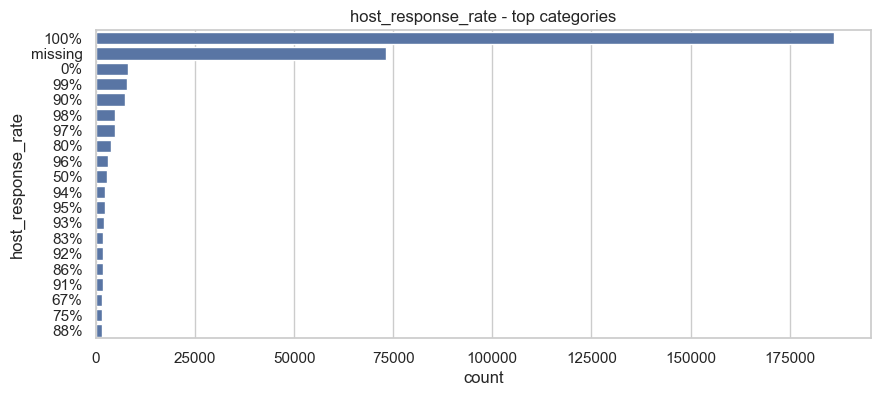


=== host_acceptance_rate ===


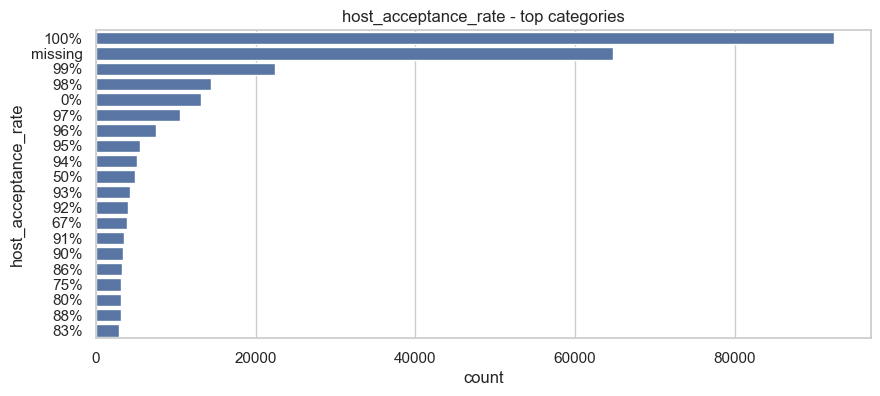


=== host_is_superhost ===


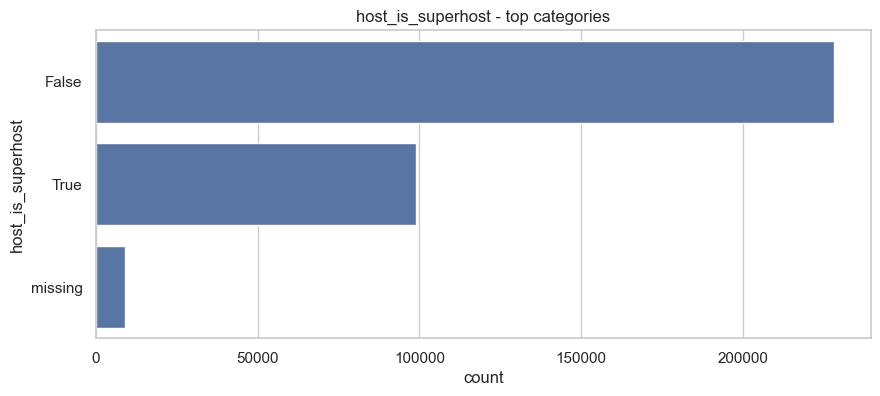


=== host_verifications ===


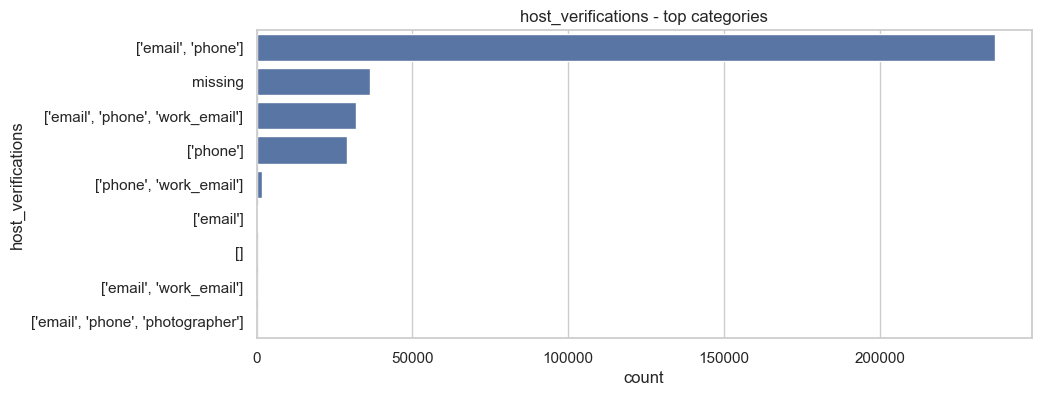


=== host_has_profile_pic ===


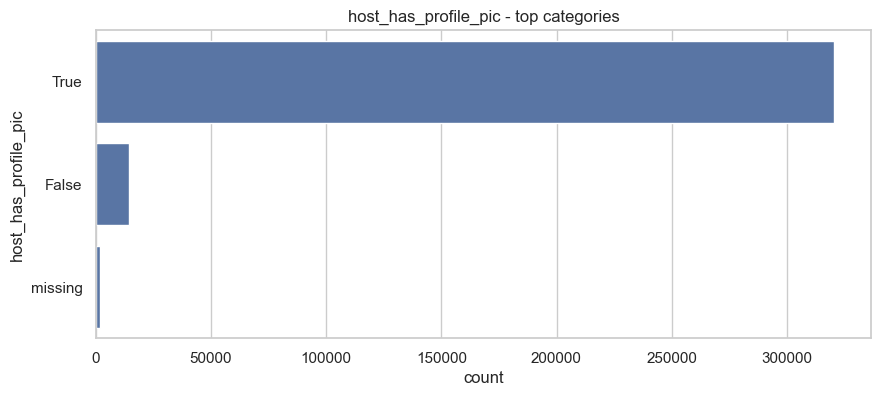


=== host_identity_verified ===


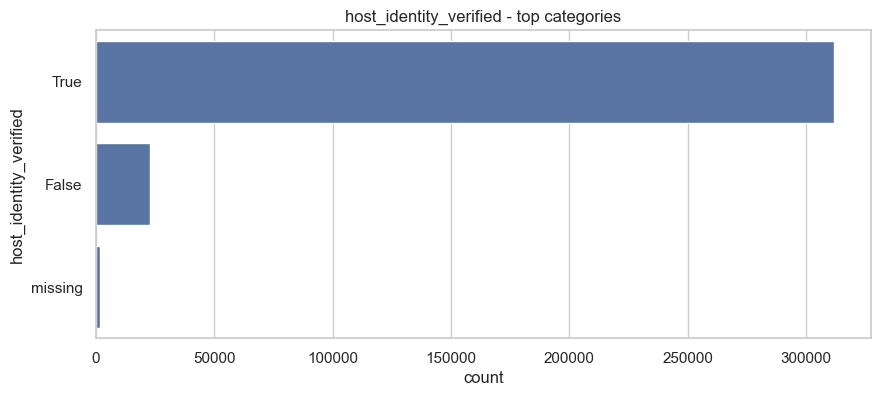


=== neighbourhood_cleansed ===


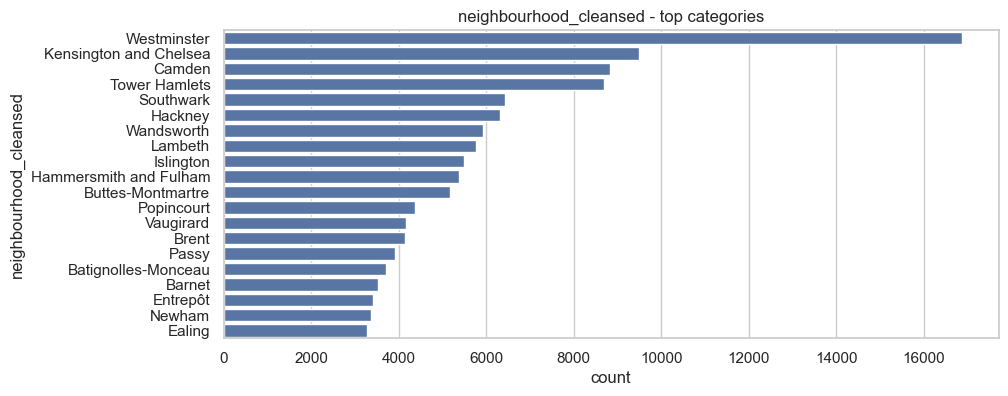


=== neighbourhood_group_cleansed ===


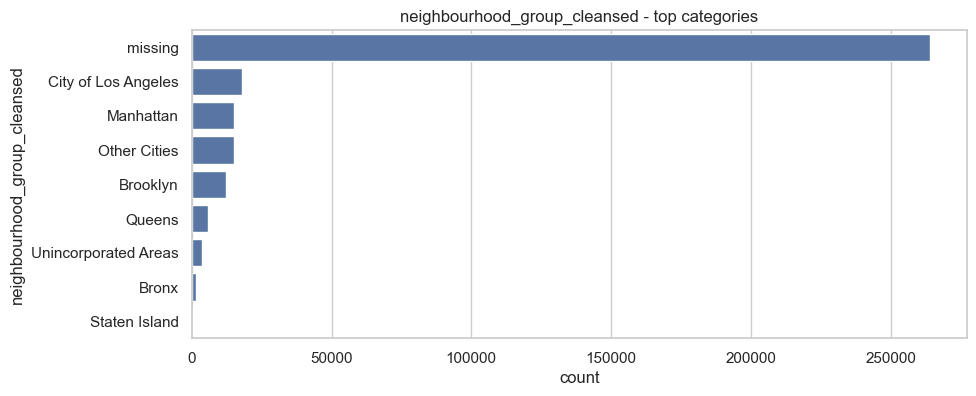


=== property_type ===


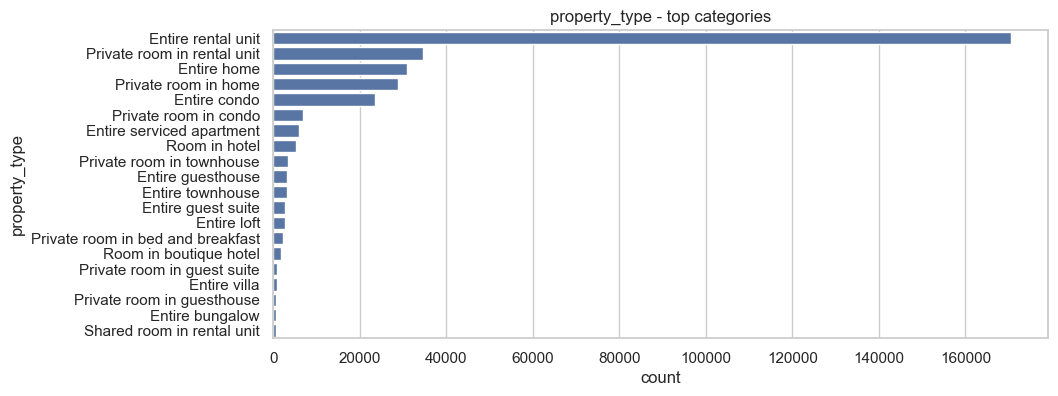


=== room_type ===


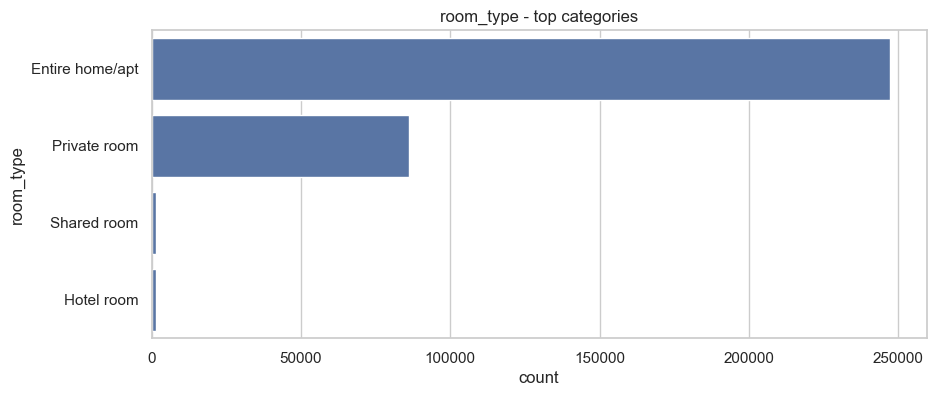


=== has_availability ===


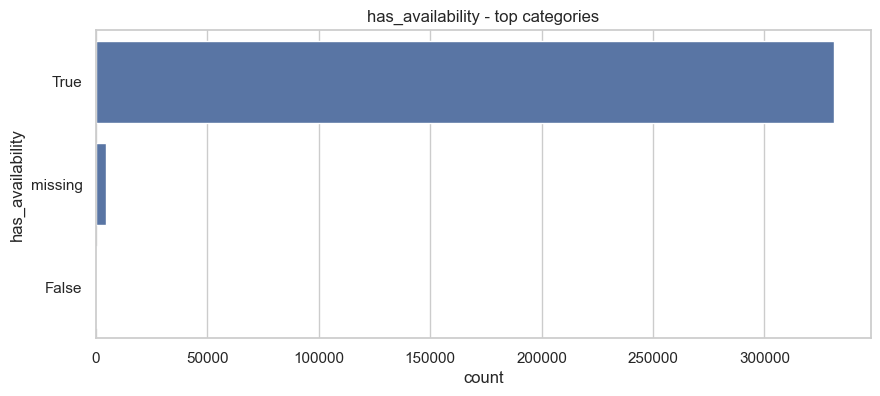


=== instant_bookable ===


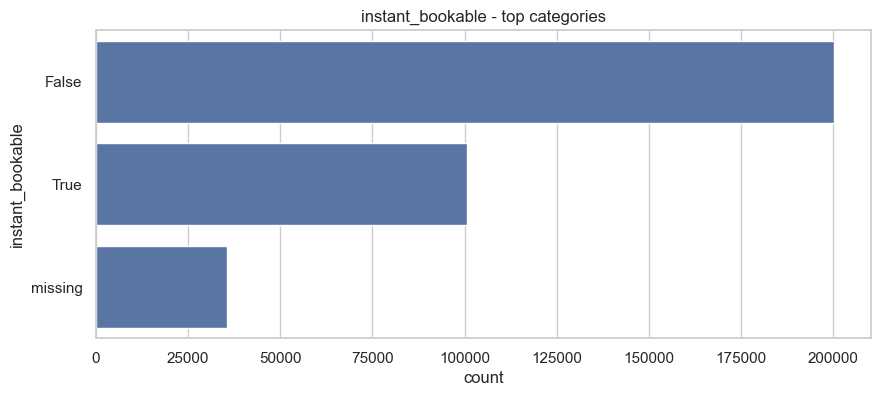


=== city ===


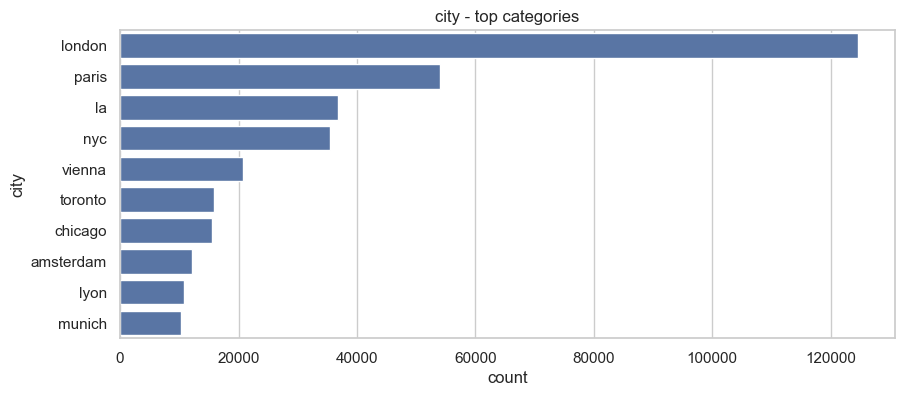

In [21]:
cat_cols = listings_ml.select_dtypes(include="object").columns.tolist()

# на всякий случай уберём текстовые поля (их в 5.4 будем смотреть отдельно)
text_like = ["name", "description", "neighborhood_overview", "amenities", "bathrooms_text"]
cat_cols = [c for c in cat_cols if c not in text_like]

for col in cat_cols:
    print(f"\n=== {col} ===")
    
    plt.figure(figsize=(10,4))
    
    # берём топ-20 категорий, чтобы график был читаемым
    value_counts = listings_ml[col].fillna("missing").value_counts().head(20)
    
    sns.barplot(x=value_counts.values, y=value_counts.index)
    
    plt.title(f"{col} - top categories")
    plt.xlabel("count")
    plt.ylabel(col)
    
    plt.show()

**Выводы:**
Рынок сильно смещён и отражает доминирование целых объектов аренды.
property_type имеет очень высокую разреженность (129 категорий), при этом основная масса данных сосредоточена в нескольких типах жилья, потребуется укрупнение категорий.
Хосты в основном не являются суперхостами (≈76%), что может быть важным сигналом качества и доверия.
Большинство объектов не instant bookable (≈70%), что может снижать конверсию и влиять на спрос.

### 5.3 Корреляционный анализ

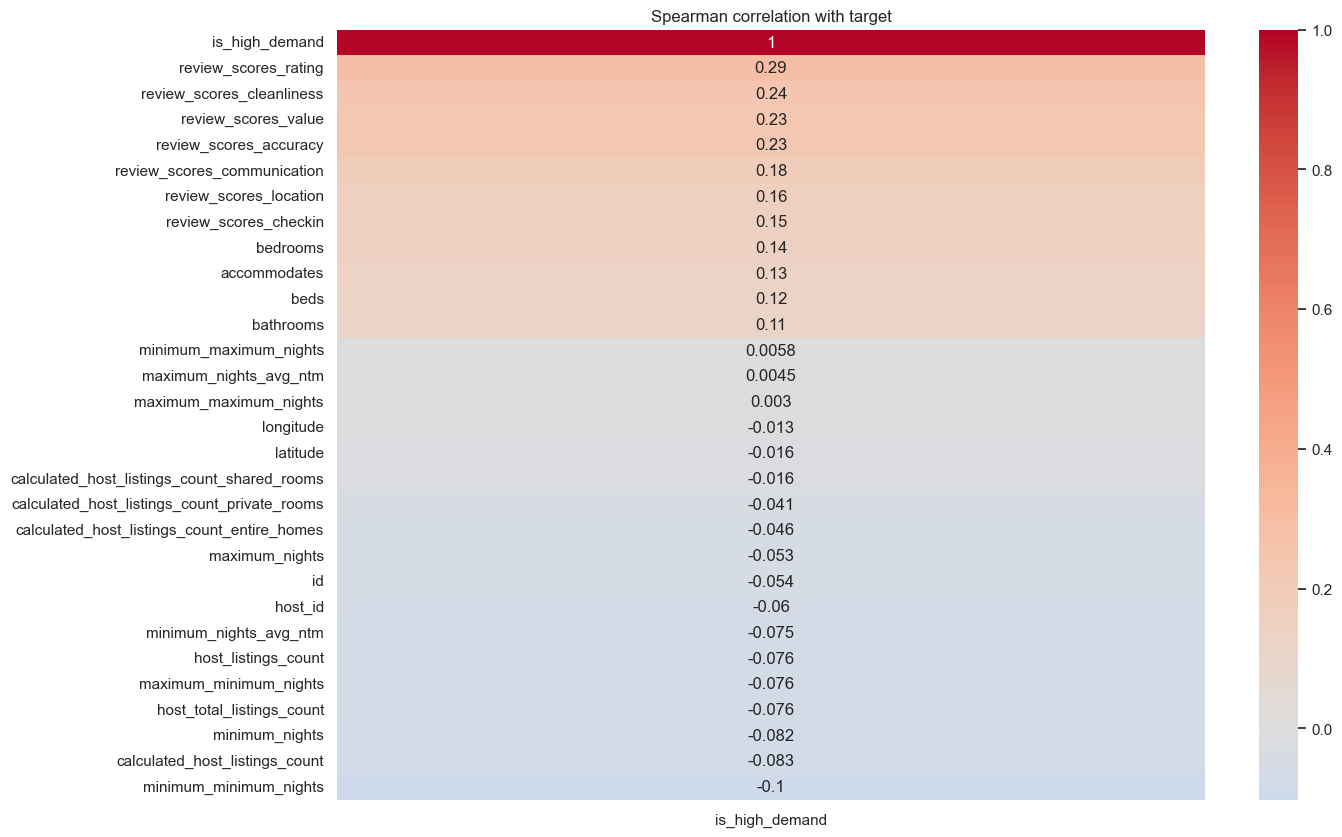

In [22]:
num_cols_corr = listings_ml.select_dtypes(include=np.number).columns.tolist()
num_cols_corr = [c for c in num_cols_corr if c != "is_high_demand"]

corr_spearman = listings_ml[num_cols_corr + ["is_high_demand"]].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr_spearman[["is_high_demand"]].sort_values("is_high_demand", ascending=False),
            annot=True,
            cmap="coolwarm",
            center=0)
plt.title("Spearman correlation with target")
plt.show()

interval columns not set, guessing: ['is_high_demand']


/Users/tcekh.xiph/miniconda3/envs/ml/lib/python3.11/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 3537390. Are interval variables set correctly?
  warnings.warn(


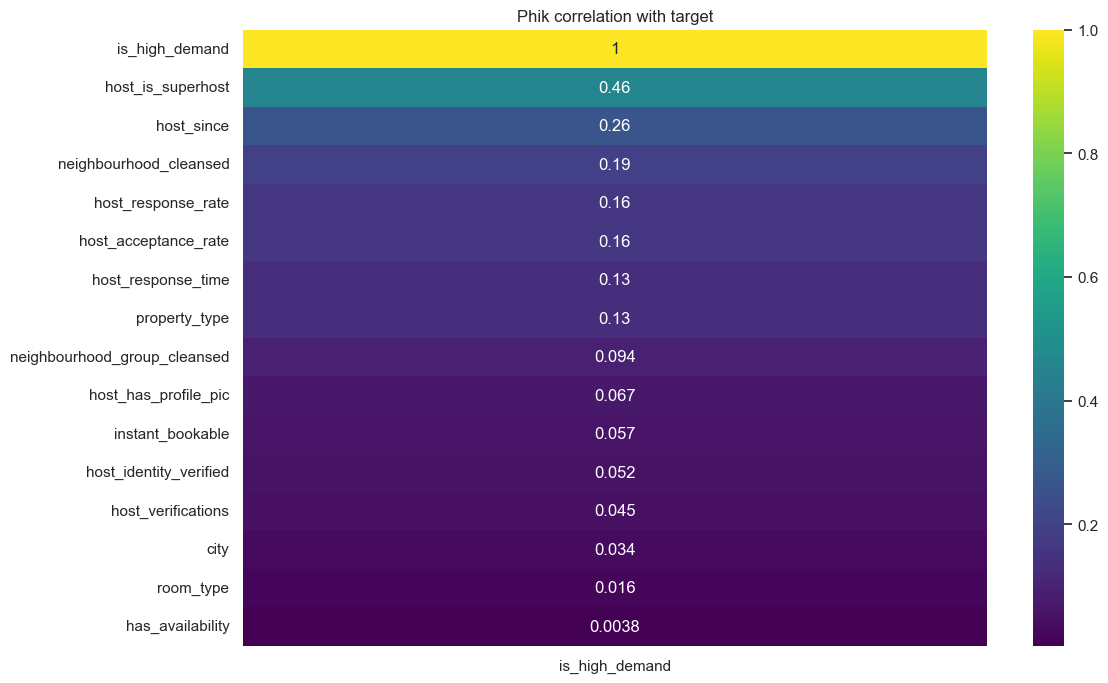

In [23]:
cat_cols_corr = listings_ml.select_dtypes(include="object").columns.tolist()

# убираем текстовые поля
text_cols = ["name", "description", "neighborhood_overview", "amenities", "bathrooms_text"]
cat_cols_corr = [c for c in cat_cols_corr if c not in text_cols]

phik_matrix = listings_ml[cat_cols_corr + ["is_high_demand"]].phik_matrix()

plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix[["is_high_demand"]].sort_values("is_high_demand", ascending=False),
            annot=True,
            cmap="viridis")
plt.title("Phik correlation with target")
plt.show()

**Выводы:**




### 5.4 Текстовые данные

Изучите названия листингов `name` и отзывы `reviews`. Сформулируйте гипотезы о том, какие текстовые признаки стоит создать.

In [24]:
review_tables = [
    "amsterdam_reviews",
    "chicago_reviews",
    "la_reviews",
    "london_reviews",
    "lyon_reviews",
    "munich_reviews",
    "nyc_reviews",
    "paris_reviews",
    "toronto_reviews",
    "vienna_reviews"
]

reviews_list = []

for t in review_tables:
    df = pd.read_sql(
        f"""
        SELECT listing_id, comments
        FROM final_project.{t}
        WHERE comments IS NOT NULL
        """,
        engine
    )
    df["city"] = t.replace("_reviews", "")
    reviews_list.append(df)

reviews_df = pd.concat(reviews_list, ignore_index=True)



Описание длины названий:


count    336249.000000
mean         44.395192
std          74.601122
min           1.000000
25%          32.000000
50%          43.000000
75%          54.000000
max       40832.000000
Name: name, dtype: float64

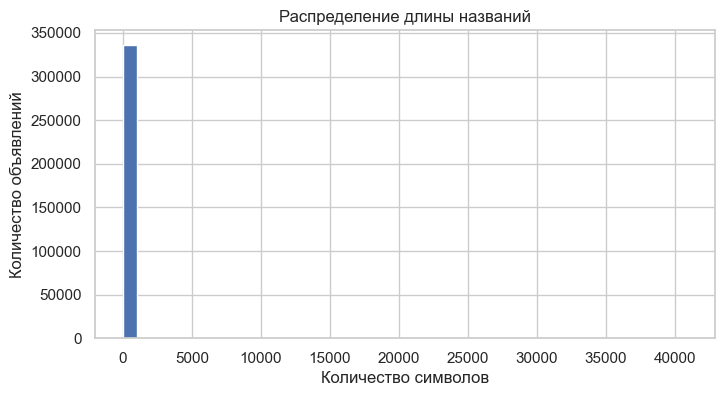


Самые частые слова в названиях


,word,count
0,в,113724
1,с,99505
2,квартира,81621
3,и,48277
4,2,40706
5,на,31578
6,комната,30569
7,1,29465
8,студия,26918
9,дом,26183



Примеры отзывов


,listing_id,comments,city
10117913,1.927912e+07,The apartment was exactly as it had been descr...,vienna
5616649,1.307259e+18,Logement assez grand. <br/>Et étrangement pais...,lyon
8176416,4.537919e+07,Très bon séjour. Juste un petit détail: le log...,paris
86841,1.708637e+06,Très bon séjour chez Ellen qui est accueillant...,amsterdam
1900529,3.442158e+07,Thank you once again!,la
7113130,3.371946e+06,Such a beautiful place to stay in Paris. Gives...,paris
1818650,2.963168e+07,"A lovely place to stay, very quiet, stylish, p...",la
1121030,1.681745e+06,Beautiful place and location. Would stay again...,la
3229843,7.906953e+06,Flat is in very good conditions and well conne...,london
10409808,7.355791e+17,"We had a nice stay, the apartment was clean an...",vienna



Описание длины отзывов:


count    1.060449e+07
mean     2.394503e+02
std      2.318381e+02
min      1.000000e+00
25%      8.400000e+01
50%      1.740000e+02
75%      3.180000e+02
max      1.201300e+04
Name: comments, dtype: float64

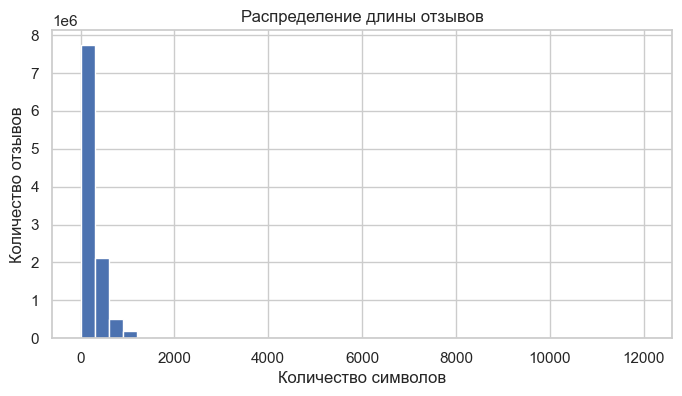

In [25]:


names = listings_ml["name"].fillna("").astype(str)

name_length = names.str.len()

print("\nОписание длины названий:")
display(name_length.describe())

plt.figure(figsize=(8,4))
plt.hist(name_length, bins=40)
plt.title("Распределение длины названий")
plt.xlabel("Количество символов")
plt.ylabel("Количество объявлений")
plt.show()

# =====================================
# Самые частые слова в названиях
# =====================================

words = []

for text in names:
    words.extend(re.findall(r"\w+", text.lower()))

top_name_words = pd.DataFrame(
    Counter(words).most_common(20),
    columns=["word", "count"]
)

print("\nСамые частые слова в названиях")
display(top_name_words)

# =====================================
# Исследование отзывов
# =====================================

print("\nПримеры отзывов")
display(reviews_df.sample(10, random_state=42))

review_length = reviews_df["comments"].astype(str).str.len()

print("\nОписание длины отзывов:")
display(review_length.describe())

plt.figure(figsize=(8,4))
plt.hist(review_length, bins=40)
plt.title("Распределение длины отзывов")
plt.xlabel("Количество символов")
plt.ylabel("Количество отзывов")
plt.show()


In [26]:
sample_reviews = reviews_df.sample(5000, random_state=42)

review_words = []

for text in sample_reviews["comments"]:
    review_words.extend(re.findall(r"\w+", str(text).lower()))

top_review_words = pd.DataFrame(
    Counter(review_words).most_common(30),
    columns=["word", "count"]
)

display(top_review_words)

,word,count
0,the,8632
1,and,8133
2,a,5497
3,to,4941
4,was,4239
5,is,3367
6,in,3278
7,very,2487
8,we,2364
9,br,2328


**Выводы:**



### 5.5 Итоги EDA

Зафиксируйте ключевые наблюдения и план по созданию новых признаков.

**Ключевые наблюдения:**




---

**Новые признаки** (реализованы в разделе 7):

| Признак | Описание | Обоснование |
|---------|----------|-------------|
| `price_per_person` | Цена за одного гостя | Позволяет сравнивать объекты разной вместимости. |
| `log_price` | Логарифм цены | Снижает влияние выбросов и асимметрии распределения цены. |
| `avg_stay_nights` | Среднее между минимальным и максимальным сроком проживания | Характеризует типичный срок аренды объекта. |
| `stay_ratio` | Отношение минимального срока к максимальному | Отражает ограничения на бронирование. |
| `host_age_days` | Возраст аккаунта хоста в днях | Более опытные хосты могут иметь более высокий спрос. |
| `host_verifications_count` | Количество способов верификации хоста | Характеризует уровень доверия к хосту. |
| `host_quality_score` | Интегральная оценка качества хоста (Superhost, верификация, response rate) | Объединяет ключевые характеристики надёжности хоста. |
| `name_length` | Длина названия объявления | Отражает информативность карточки. |
| `name_word_count` | Количество слов в названии | Дополнительная характеристика описания объявления. |
| `desc_length` | Длина описания | Более подробные описания могут положительно влиять на спрос. |
| `amenities_count` | Количество удобств | Позволяет оценить оснащённость жилья. |
| `bathrooms_per_guest` | Количество ванных комнат на одного гостя | Характеризует комфорт размещения. |
| `bedrooms_per_guest` | Количество спальных мест на одного гостя | Отражает удобство размещения гостей. |

## 6. Обработка пропусков (если необходимо)

Обработайте пропуски согласно стратегии, выработанной в результате EDA. Все решения обоснуйте.

In [27]:
# =====================================
# 6.1 Разделение данных на train и test
# =====================================

data = listings_ml.copy()

drop_cols = [

    # идентификаторы
    "id",
    "host_id",
    "source",

    # признаки с высокой кардинальностью
    "amenities",
    "host_verifications",

    # признаки, созданные при расчете target
    "median_reviews_ltm",
    "median_price",
    "median_rating",
    "price_ratio",
    "rating_ratio"
]


X = data.drop(
    columns=drop_cols + ["is_high_demand"],
    errors="ignore"
)

y = data["is_high_demand"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)


print("Размер train:", X_train.shape)
print("Размер test:", X_test.shape)


print("\nБаланс классов train:")
display(
    y_train.value_counts(normalize=True)
)


print("\nБаланс классов test:")
display(
    y_test.value_counts(normalize=True)
)

Размер train: (268999, 45)
Размер test: (67250, 45)

Баланс классов train:


is_high_demand
0    0.876799
1    0.123201
Name: proportion, dtype: float64


Баланс классов test:


is_high_demand
0    0.876803
1    0.123197
Name: proportion, dtype: float64

In [28]:
# =====================================
# 6.2 Анализ пропусков
# =====================================

missing_train = (
    X_train
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(
    missing_train[missing_train > 0]
)

neighbourhood_group_cleansed    0.784706
neighborhood_overview           0.610541
host_response_time              0.217131
host_response_rate              0.217131
review_scores_location          0.215926
review_scores_checkin           0.215923
review_scores_value             0.215923
review_scores_accuracy          0.215900
review_scores_cleanliness       0.215897
review_scores_communication     0.215897
review_scores_rating            0.215852
host_acceptance_rate            0.193008
host_since                      0.108216
host_total_listings_count       0.108216
instant_bookable                0.105562
host_is_superhost               0.026781
description                     0.025431
has_availability                0.013108
host_listings_count             0.004703
host_has_profile_pic            0.004703
host_identity_verified          0.004703
bedrooms                        0.002368
beds                            0.002097
bathrooms_text                  0.001375
bathrooms       

In [ ]:
# =====================================
# 6.4 Реализация обработки пропусков
# =====================================

# =====================================
# 1. Удаление признаков с >50% пропусков
# =====================================

missing_share = (
    X_train
    .isna()
    .mean()
)


cols_to_drop = (
    missing_share[
        missing_share > 0.5
    ]
    .index
    .tolist()
)


print("Удаляем признаки:")
print(cols_to_drop)


X_train = X_train.drop(
    columns=cols_to_drop
)

X_test = X_test.drop(
    columns=cols_to_drop
)



# =====================================
# 2. Создаем объект preprocessing
# для передачи в inference
# =====================================

fill_values = {

    "drop_columns": cols_to_drop,

    "numeric": {},

    "categorical": {}

}



# =====================================
# 3. Обработка дат
# =====================================

date_cols = X_train.select_dtypes(
    include=[
        "datetime64[ns]",
        "datetime64"
    ]
).columns


print(
    "Дата признаки:",
    list(date_cols)
)


for col in date_cols:

    fill_values["categorical"][col] = "Unknown"


    X_train[col] = (
        X_train[col]
        .fillna(
            pd.Timestamp("2000-01-01")
        )
        .astype(str)
    )


    X_test[col] = (
        X_test[col]
        .fillna(
            pd.Timestamp("2000-01-01")
        )
        .astype(str)
    )



# =====================================
# 4. Числовые признаки
# Заполняем медианой train
# =====================================

num_cols = X_train.select_dtypes(
    include=["number"]
).columns


print(
    "Числовые признаки:",
    len(num_cols)
)


for col in num_cols:


    if X_train[col].isna().sum() > 0:


        median_value = (
            X_train[col]
            .median()
        )


        fill_values["numeric"][col] = (
            median_value
        )


        X_train[col] = (
            X_train[col]
            .fillna(
                median_value
            )
        )


        X_test[col] = (
            X_test[col]
            .fillna(
                median_value
            )
        )



# =====================================
# 5. Категориальные признаки
# =====================================

cat_cols = X_train.select_dtypes(
    include=[
        "object",
        "bool"
    ]
).columns


print(
    "Категориальные признаки:",
    len(cat_cols)
)


for col in cat_cols:


    fill_values["categorical"][col] = (
        "Unknown"
    )


    X_train[col] = (
        X_train[col]
        .fillna(
            "Unknown"
        )
        .astype(str)
    )


    X_test[col] = (
        X_test[col]
        .fillna(
            "Unknown"
        )
        .astype(str)
    )



# =====================================
# 6. Финальный список категорий
# =====================================

cat_features = (
    X_train
    .select_dtypes(
        include=[
            "object"
        ]
    )
    .columns
    .tolist()
)


print(
    "CatBoost categorical features:",
    len(cat_features)
)



# =====================================
# 7. Сохраняем параметры
# для inference DAG
# =====================================

with open(
    "fill_values.pkl",
    "wb"
) as f:

    pickle.dump(
        fill_values,
        f
    )


with open(
    "cat_features.pkl",
    "wb"
) as f:

    pickle.dump(
        cat_features,
        f
    )



# =====================================
# 8. Проверка результата
# =====================================

print("\nПропуски train:")

display(
    X_train
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    .head()
)


print("\nПропуски test:")

display(
    X_test
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    .head()
)


print(
    "\nРазмер train:",
    X_train.shape
)

print(
    "Размер test:",
    X_test.shape
)


print(
    "\nСохранены параметры:"
)

print(
    "Drop columns:",
    len(fill_values["drop_columns"])
)

print(
    "Numeric fill:",
    len(fill_values["numeric"])
)

print(
    "Categorical fill:",
    len(fill_values["categorical"])
)

print(
    "Cat features:",
    len(cat_features)
)

Удаляем признаки:
[]
Дата признаки: []
Числовые признаки: 34
Категориальные признаки: 17
CatBoost categorical features: 17

Пропуски train:


name                              0.0
calculated_host_listings_count    0.0
maximum_nights_avg_ntm            0.0
has_availability                  0.0
review_scores_rating              0.0
dtype: float64


Пропуски test:


name                              0.0
calculated_host_listings_count    0.0
maximum_nights_avg_ntm            0.0
has_availability                  0.0
review_scores_rating              0.0
dtype: float64


Размер train: (268999, 51)
Размер test: (67250, 51)

Сохранены параметры:
Drop columns: 0
Numeric fill: 0
Categorical fill: 17
Cat features: 17


### Стратегия обработки пропусков

| Тип признаков | Стратегия | Обоснование |
|--------------|-----------|-------------|
| `neighborhood_overview`, `neighbourhood_group_cleansed` | удаление | Более 50% пропусков, признаки содержат недостаточно информации. |
| Числовые признаки | заполнение медианой | Медиана устойчива к выбросам и позволяет сохранить все наблюдения. |
| Категориальные признаки | заполнение значением `"Unknown"` | Пропуски выделяются в отдельную категорию без потери объектов. |

**Результат обработки:**
- удалено 2 признака с долей пропусков более 50%;
- все оставшиеся пропуски успешно заполнены;


## 7. Feature Engineering (если необходимо)

Создайте новые признаки, обоснованные EDA.

In [37]:
# =====================================
# 7. Feature Engineering
# =====================================

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()


# =====================================
# 1. Условия проживания
# =====================================

for df in [X_train_fe, X_test_fe]:

    max_nights_clean = (
        df["maximum_nights"]
        .clip(upper=1125)
    )


    df["avg_stay_nights"] = (
        df["minimum_nights"] +
        max_nights_clean
    ) / 2


    df["stay_ratio"] = (
        df["minimum_nights"] /
        max_nights_clean.replace(0, np.nan)
    )



# =====================================
# 2. Текстовые характеристики
# =====================================

for df in [X_train_fe, X_test_fe]:

    df["name_length"] = (
        df["name"]
        .fillna("")
        .str.len()
    )


    df["name_word_count"] = (
        df["name"]
        .fillna("")
        .str.split()
        .str.len()
    )


    df["desc_length"] = (
        df["description"]
        .fillna("")
        .str.len()
    )



# =====================================
# 3. Соотношения характеристик жилья
# =====================================

for df in [X_train_fe, X_test_fe]:

    df["bathrooms_per_guest"] = (
        df["bathrooms"] /
        df["accommodates"].replace(0,np.nan)
    )


    df["beds_per_guest"] = (
        df["beds"] /
        df["accommodates"].replace(0,np.nan)
    )



# =====================================
# Проверка новых признаков
# =====================================

new_features = [
    "avg_stay_nights",
    "stay_ratio",
    "name_length",
    "name_word_count",
    "desc_length",
    "bathrooms_per_guest",
    "beds_per_guest"
]


print(
    "Количество созданных признаков:",
    len(new_features)
)


display(
    X_train_fe[new_features].head()
)


print("\nПропуски:")
display(
    X_train_fe[new_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

Количество созданных признаков: 7


,avg_stay_nights,stay_ratio,name_length,name_word_count,desc_length,bathrooms_per_guest,beds_per_guest
125326,183.0,0.002740,52,8,483,0.25,0.50
71635,563.0,0.000889,45,5,214,0.50,0.50
158254,183.0,0.002740,39,5,467,3.00,0.50
104174,11.0,0.100000,38,6,525,0.50,1.00
54660,197.5,0.082192,37,5,110,0.25,0.25



Пропуски:


avg_stay_nights        0.0
stay_ratio             0.0
name_length            0.0
name_word_count        0.0
desc_length            0.0
bathrooms_per_guest    0.0
beds_per_guest         0.0
dtype: float64

### Созданные признаки и обоснование

## 8. Кодирование и масштабирование (если необходимо)

Закодируйте категориальные признаки. Примените масштабирование там, где оно нужно. Объясните, для каких моделей необходимы такие преобразования и почему.

In [38]:
# =====================================
# 8. Кодирование и масштабирование признаков
# Мультиязычный TF-IDF (RU + EN + ES + KO)
# =====================================


X_train = X_train_fe.copy()
X_test = X_test_fe.copy()



# =====================================
# 1. Создание текстового признака
# =====================================

for df in [X_train, X_test]:

    df["text_features"] = (
        df["name"]
        .fillna("")
        .astype(str)
        +
        " "
        +
        df["description"]
        .fillna("")
        .astype(str)
    )


    # нормализация Unicode
    df["text_features"] = (
        df["text_features"]
        .apply(
            lambda x: unicodedata.normalize(
                "NFKC",
                x
            )
        )
    )



# =====================================
# 2. Исключаем ненужные признаки
# =====================================


exclude_cols = [

    # текст
    "name",
    "description",
    "neighborhood_overview",
    "text_features",

    # ID
    "id",
    "host_id",

    # дата
    "first_review",
    "last_review",

    # цена убрана
    "price",
    "price_per_person",
    "log_price"

]



# =====================================
# 3. Определение типов
# =====================================


cat_features = X_train.select_dtypes(
    include=["object", "bool"]
).columns.tolist()



cat_features = [
    col 
    for col in cat_features
    if col not in exclude_cols
]



num_features = X_train.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).columns.tolist()



num_features = [
    col
    for col in num_features
    if col not in exclude_cols
]



print("Количество числовых:", len(num_features))
print(num_features)


print("\nКоличество категориальных:", len(cat_features))
print(cat_features)



# =====================================
# 4. Числовой pipeline
# =====================================


num_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]
)



# =====================================
# 5. Категориальный pipeline
# =====================================


cat_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )

    ]
)



# =====================================
# 6. Мультиязычный TF-IDF
# =====================================


multi_stop_words = [

    # English
    "the","a","an","and","or",
    "but","is","are","was",
    "were","with","for","to",
    "of","in","on","at",

    # Russian
    "и","в","во","не","что",
    "он","она","они","с",
    "как","а","это","из",

    # Spanish
    "el","la","los","las",
    "un","una","y","o",
    "de","en","con","para",

    # Korean particles/common
    "이","그","저",
    "은","는","이","가",
    "을","를","에","와","과"

]



tfidf_transformer = Pipeline(
    steps=[

        (
            "tfidf",

            TfidfVectorizer(

                lowercase=True,

                max_features=50000,

                ngram_range=(1,2),

                min_df=3,

                max_df=0.95,

                stop_words=multi_stop_words,

                sublinear_tf=True

            )
        )

    ]
)



# =====================================
# 7. Общий preprocessing
# =====================================


preprocessor = ColumnTransformer(

    transformers=[


        (
            "num",
            num_transformer,
            num_features
        ),


        (
            "cat",
            cat_transformer,
            cat_features
        ),


        (
            "text",
            tfidf_transformer,
            "text_features"
        )

    ],

    remainder="drop"

)



print("\nPreprocessor создан успешно")


Количество числовых: 34
['host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'avg_stay_nights', 'stay_ratio', 'name_length', 'name_word_count', 'desc_length', 'bathrooms_per_guest', 'beds_per_guest']

Количество категориальных: 14
['host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_

In [32]:
print("Количество числовых:", len(num_features))
print("Количество категориальных:", len(cat_features))

print("\nПример текста после очистки:")
display(X_train["text_features"].head())

Количество числовых: 34
Количество категориальных: 14

Пример текста после очистки:


125326    «Oxford Street Location» Уютный номер за 4 чел...
71635     Апартаменты-студио «Найтсбридж» — Нижний этаж ...
158254    Удивительная комната на Commercial Road Beauti...
104174    Семейный номер с общей ванной комнатой Located...
54660     Уютный дом для длительного проживания You'll h...
Name: text_features, dtype: object


**Решения по кодированию и масштабированию**

Для подготовки данных к обучению был использован `ColumnTransformer`, позволяющий применять разные преобразования к различным типам признаков.

- **Числовые признаки** были масштабированы с помощью `StandardScaler`. Это приводит признаки к единому масштабу (среднее 0, стандартное отклонение 1), что улучшает работу линейных моделей и обеспечивает сопоставимость признаков.

- **Категориальные признаки** были закодированы методом `OneHotEncoder` с параметрами `handle_unknown="ignore"` и `drop="first"`. Такой подход переводит категориальные значения в бинарные признаки, позволяет корректно обрабатывать новые категории при инференсе и уменьшает избыточность кодирования.

- **Высококардинальные текстовые признаки** (`name`, `description`, `review_text`, `amenities`, `host_verifications`) были исключены из модели. Их обработка потребовала бы отдельного конвейера (например, TF-IDF или эмбеддингов), что не входило в текущую реализацию.

- **Идентификаторы объектов** (`id`, `host_id`, `source`) были удалены, так как не несут полезной информации для прогнозирования.

- **Признаки, содержащие информацию о целевой переменной** (`median_reviews_ltm`, `median_price`, `median_rating`, `price_ratio`, `rating_ratio`), были исключены для предотвращения утечки данных (data leakage).

В результате был сформирован единый объект `preprocessor`, который использовался как при обучении модели, так и при последующем инференсе, что обеспечивает одинаковую обработку данных на всех этапах проекта.

## 9. Деление на выборки

Разделите данные на обучающую и тестовую выборки. Обоснуйте пропорции и стратегию разделения.

In [33]:
# прсто утверждаем и выводим значения и сверяем со всем
# =====================================
# Проверка разделения train/test
# =====================================

print("Размер train:", X_train.shape)
print("Размер test:", X_test.shape)


print("\nБаланс классов train:")
print(
    y_train.value_counts(normalize=True)
)


print("\nБаланс классов test:")
print(
    y_test.value_counts(normalize=True)
)

Размер train: (268999, 51)
Размер test: (67250, 51)

Баланс классов train:
is_high_demand
0    0.876799
1    0.123201
Name: proportion, dtype: float64

Баланс классов test:
is_high_demand
0    0.876803
1    0.123197
Name: proportion, dtype: float64


### Параметры разбивки и обоснование

Для оценки качества модели данные были разделены на обучающую и тестовую выборки с помощью функции `train_test_split`.

- **Размер тестовой выборки (`test_size=0.2`)** — 20% данных использованы для финальной оценки качества модели, 80% — для обучения.
- **Фиксированное случайное состояние (`random_state=42`)** обеспечивает воспроизводимость результатов.
- **Стратификация (`stratify=y`)** позволяет сохранить одинаковое соотношение классов в обучающей и тестовой выборках, что особенно важно при наличии дисбаланса классов.

Такой подход обеспечивает корректную оценку качества модели на ранее не использовавшихся данных и соответствует стандартной практике построения моделей машинного обучения.

## 10. Сохранение готового датасета
Сохраните готовый датасет, используя библиотеку joblib.

In [39]:
# =====================================
# 9. Сохранение готового датасета
# =====================================

# сохраняем признаки train/test

joblib.dump(
    X_train,
    "X_train.pkl"
)

joblib.dump(
    X_test,
    "X_test.pkl"
)


# сохраняем целевую переменную

joblib.dump(
    y_train,
    "y_train.pkl"
)

joblib.dump(
    y_test,
    "y_test.pkl"
)


# сохраняем preprocessing pipeline

joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)


print("Данные и preprocessing успешно сохранены")


# проверка наличия файлов

print("\nСохраненные файлы:")

for file in [
    "X_train.pkl",
    "X_test.pkl",
    "y_train.pkl",
    "y_test.pkl",
    "preprocessor.pkl"
]:
    print("✓", file)

Данные и preprocessing успешно сохранены

Сохраненные файлы:
✓ X_train.pkl
✓ X_test.pkl
✓ y_train.pkl
✓ y_test.pkl
✓ preprocessor.pkl


## 11. Итоговые выводы

Опишите проделанную работу: какие действия выполняли, что получилось, какие вопросы остались открытыми.

**Выводы по EDA и подготовке данных:**

### Выводы по EDA и подготовке данных

1. Выполнено объединение данных из таблиц **listings**, **calendar** и **reviews**, после чего сформирован единый датасет для обучения модели.

2. Построен целевой признак **`is_high_demand`**, отражающий высокий спрос на объект. Для расчёта использовались медианные значения внутри сегментов **`city + room_type`**, что позволило учитывать различия между городами и типами жилья.

3. Для предотвращения **data leakage** из набора данных были удалены признаки, содержащие информацию о будущих бронированиях, количестве отзывов, загрузке календаря и производные агрегаты, напрямую связанные с целевой переменной.

4. Выполнена обработка пропусков: признаки с большим количеством отсутствующих значений удалены, числовые пропуски заполнены медианой, категориальные — значением `"Unknown"`.

5. Проведена генерация новых признаков, описывающих стоимость проживания, характеристики хоста, параметры размещения, текстовое описание объявления и удобства. Полученные признаки позволили расширить информацию, доступную модели.

6. Для подготовки данных к обучению категориальные признаки были закодированы с помощью **One-Hot Encoding**, числовые — масштабированы с использованием **StandardScaler**. Все преобразования объединены в единый `ColumnTransformer`, который был сохранён для последующего использования во время инференса.

7. Данные были разделены на обучающую и тестовую выборки в соотношении **80/20** с использованием стратификации по целевой переменной, что позволило сохранить исходный баланс классов и обеспечить корректную оценку качества модели.

